# Compare the gene expression between Xin/Orlando (microarray) and Yulong (RNA-seq)

The motivation of this notebook, is that the deconvolution is having some trouble with the TPM values of the gene expression. However, the microarray dataset appears to deconvolve properly. Most notably in RNR1. On inspection, the value ranges of the two assays appear much different.

So in this notebook we will plot the distributions to better compare the technologies, and show how the DESeq2 VST transformation improves the range so that it is comparable to the microarray deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


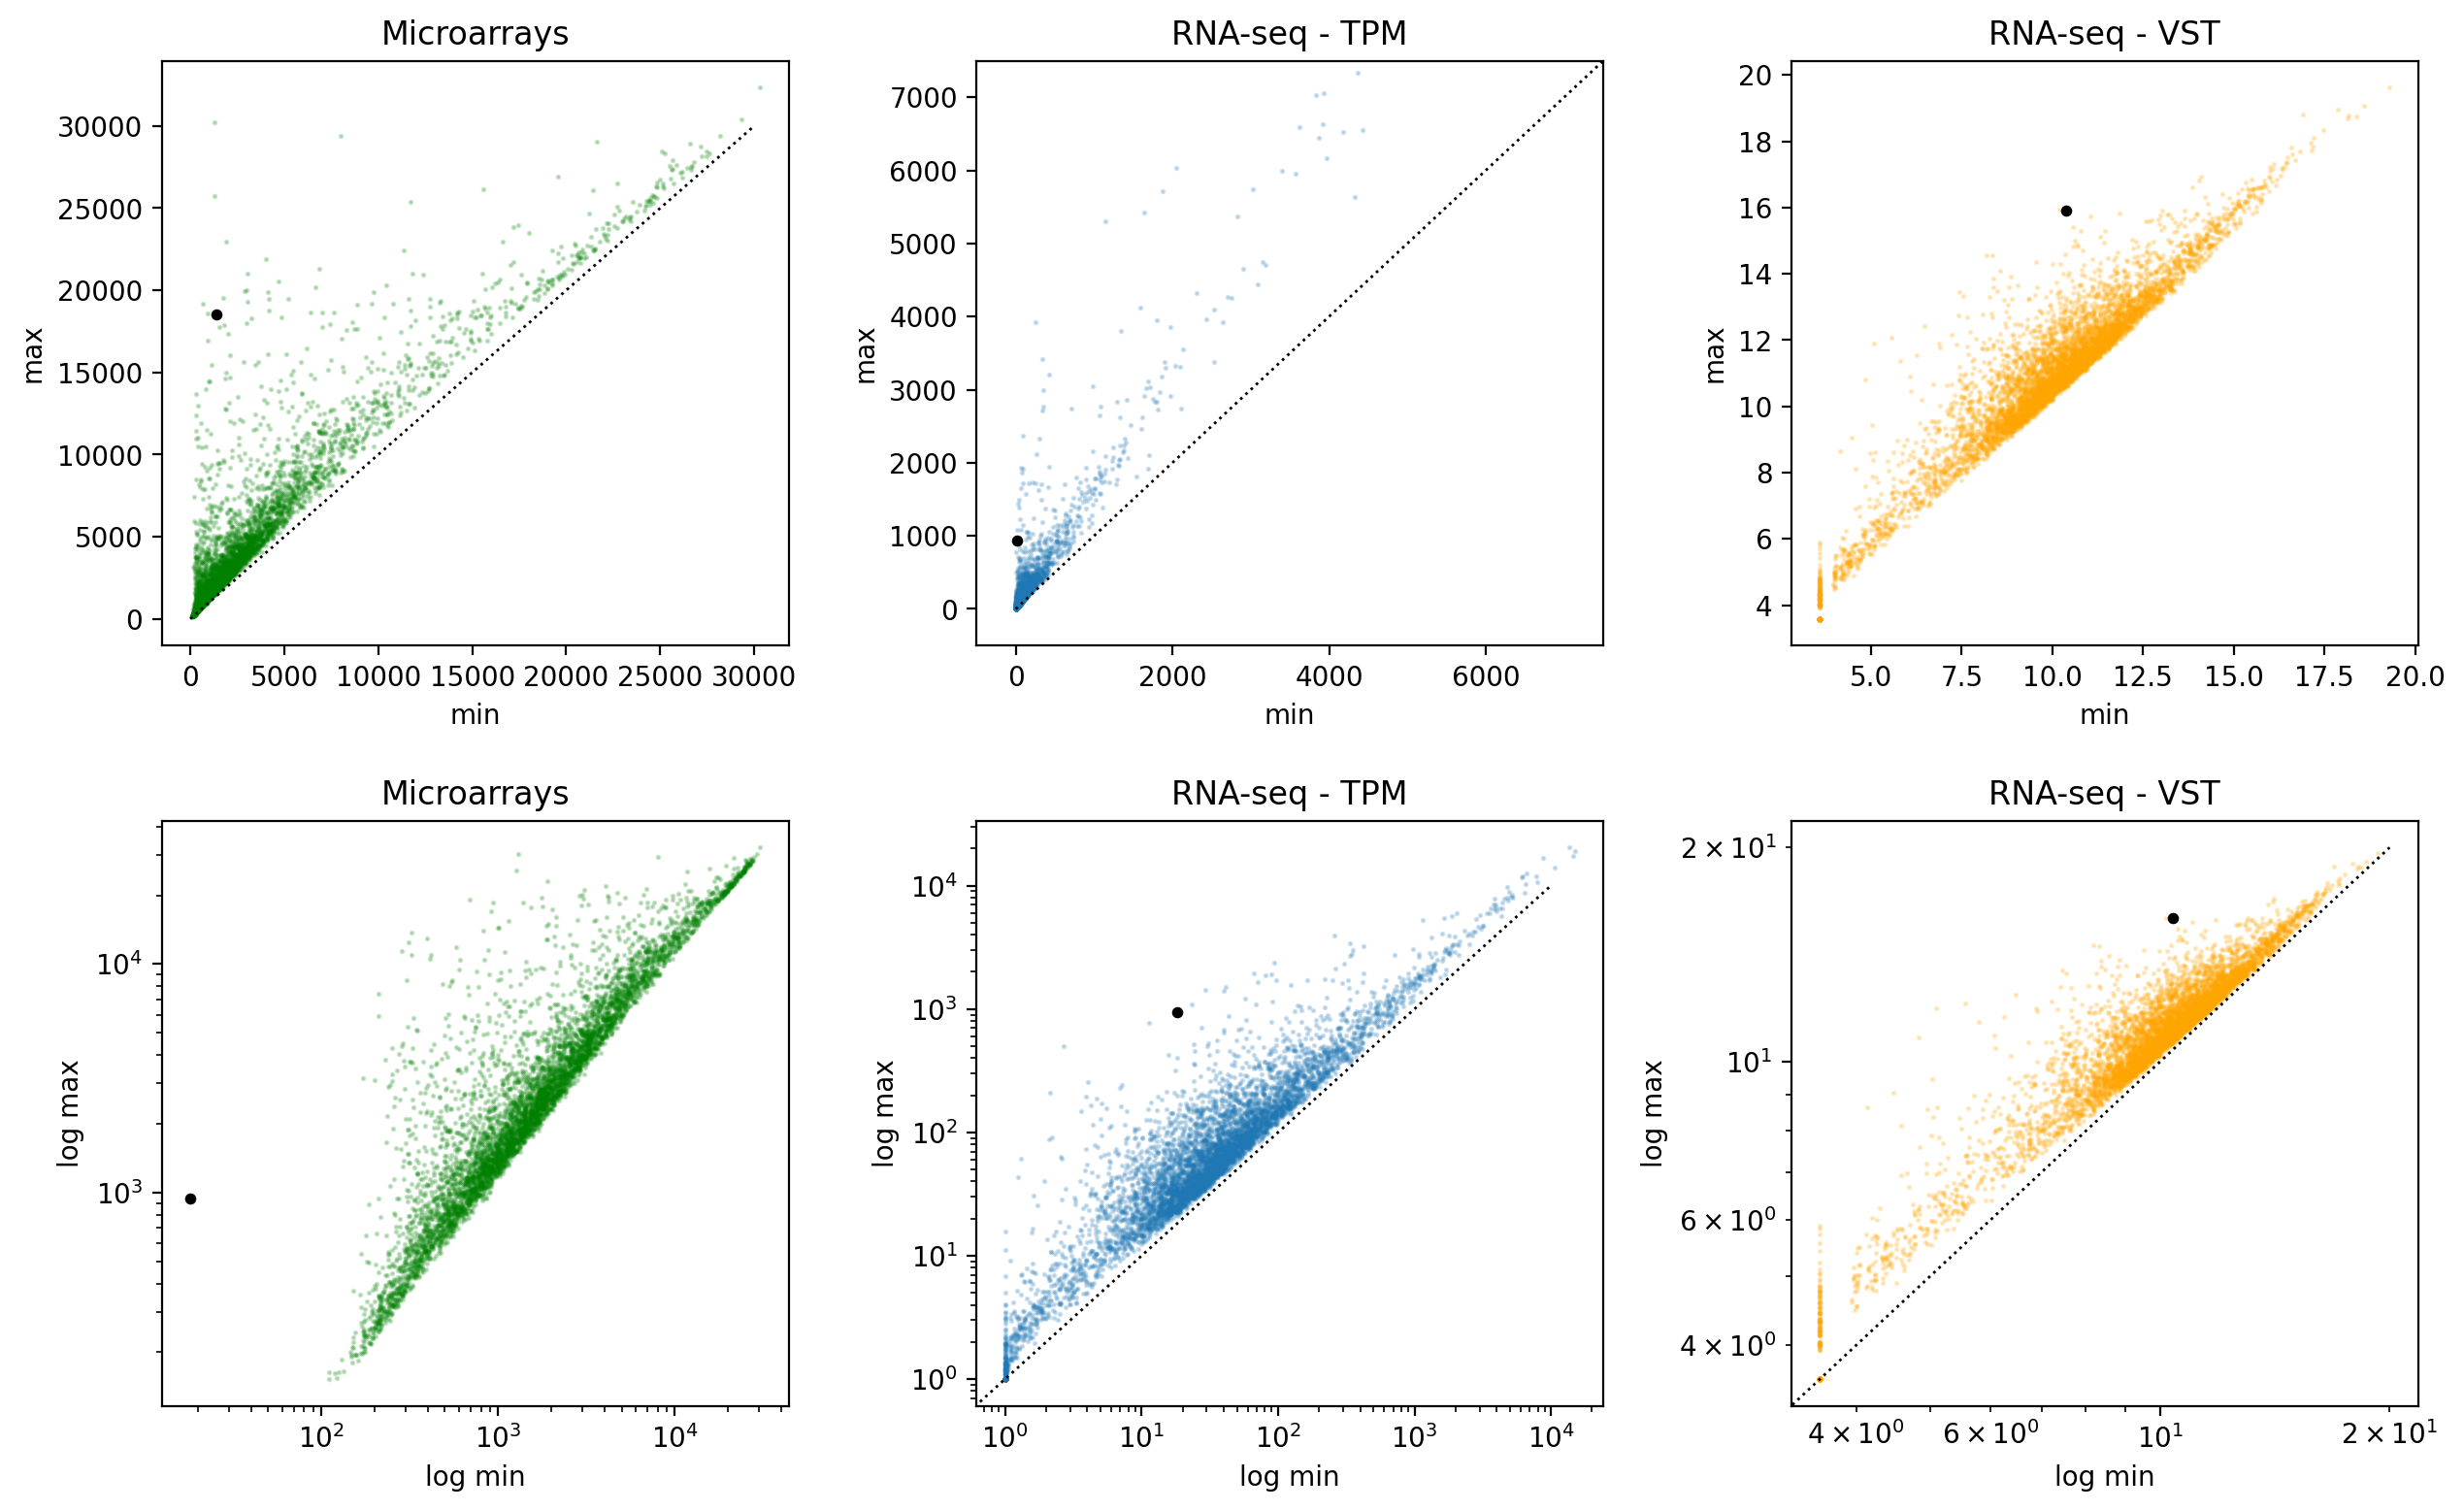

In [2]:
from src.normalization_analysis import NormAnalysis

norm_analysis = NormAnalysis()
norm_analysis.compute_meta()
norm_analysis.plot_differences()

Gene expression:
	Min: 10.39
	Max: 15.92


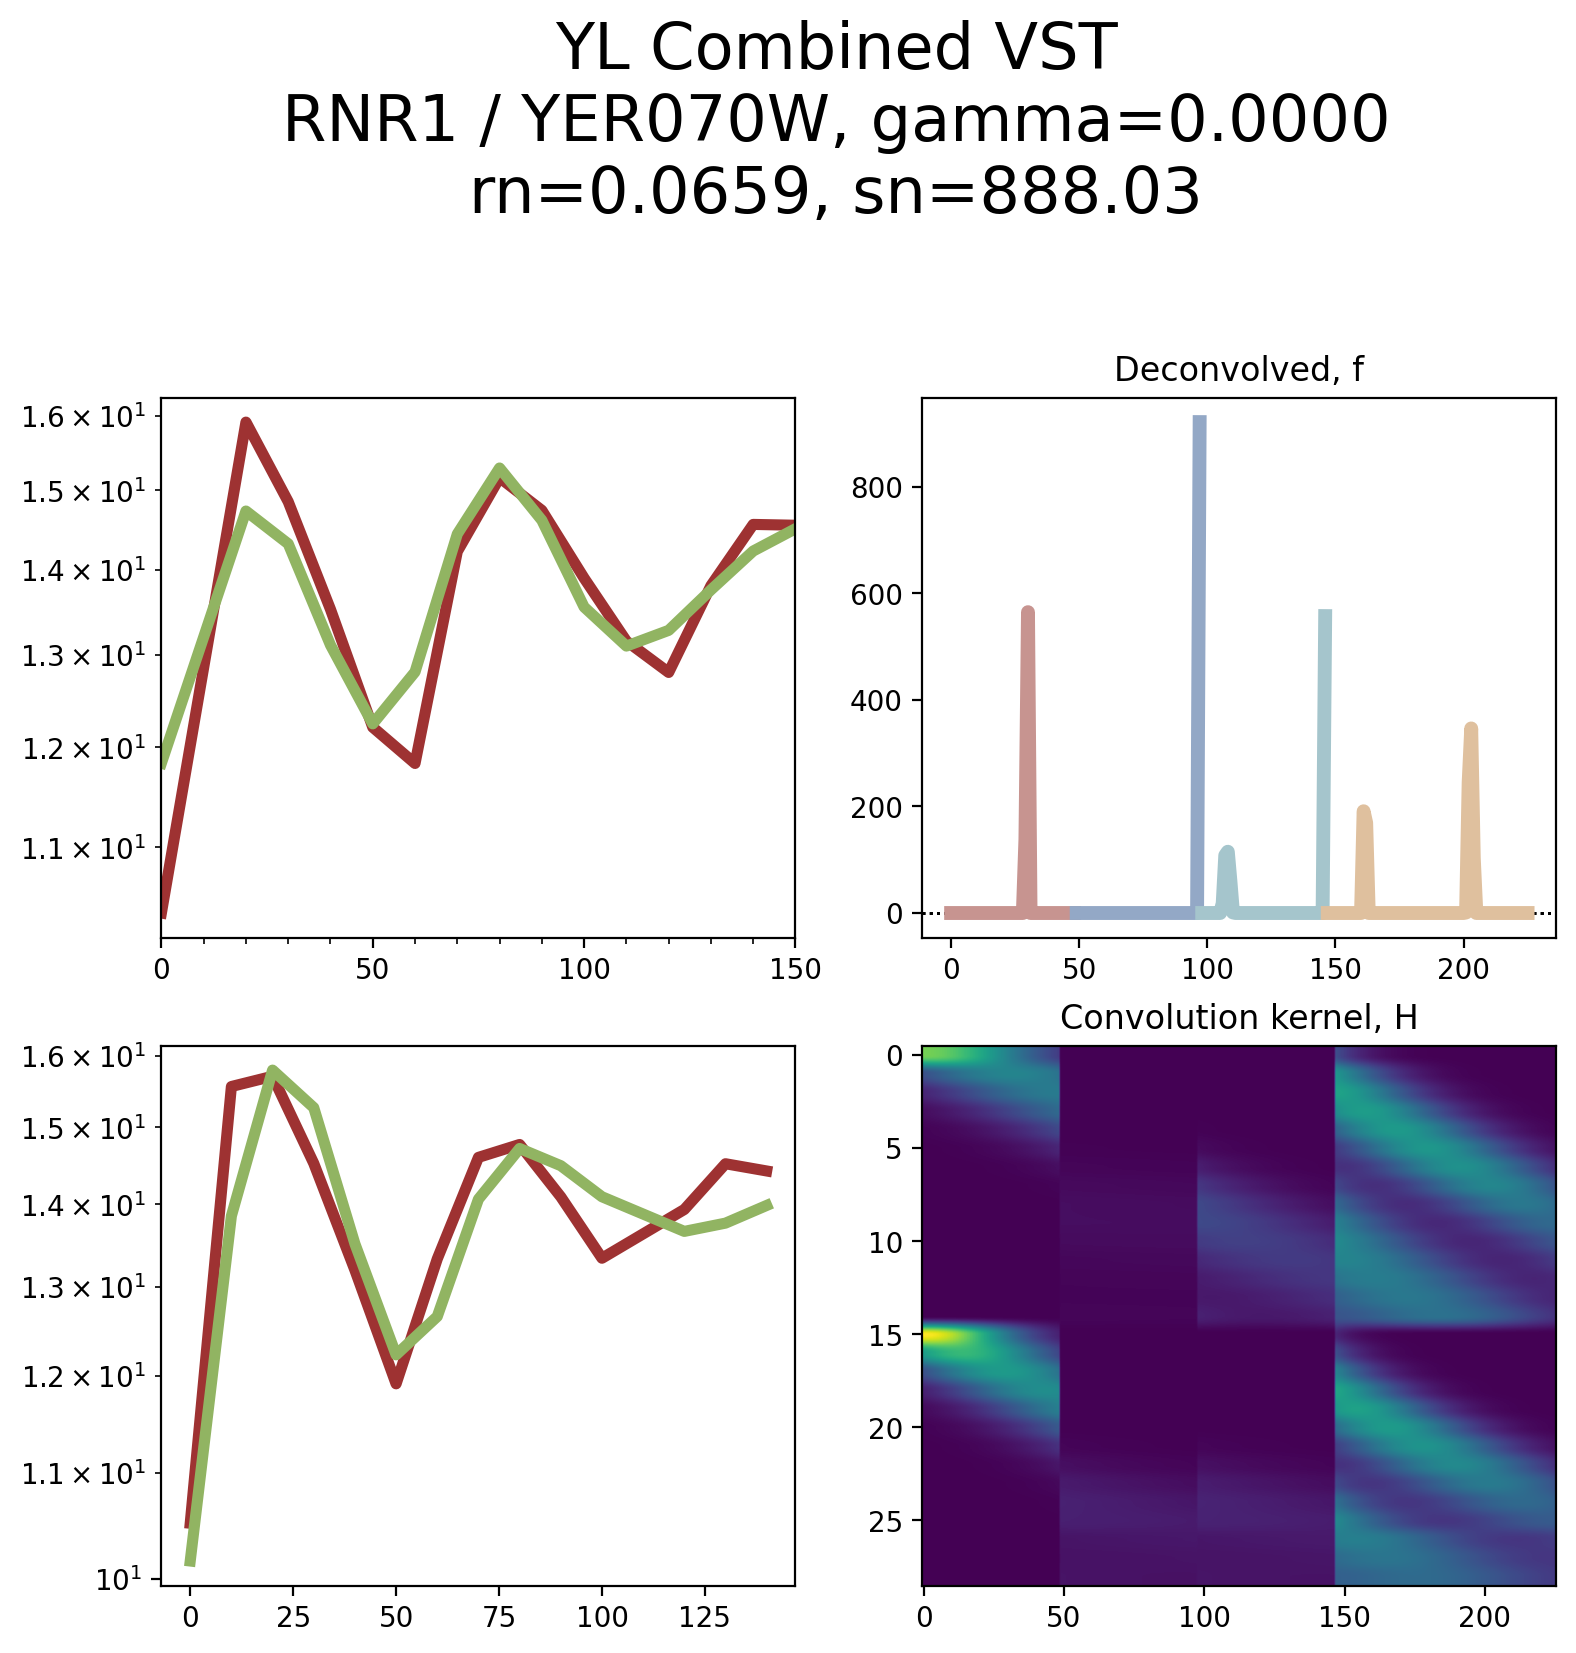

In [3]:
# Let's plot RNR1's gene expression values across these data types to show the
# difference in deconvolution quality

from src.config import load_combined_yl_vst_gene_expression_config
from src.model import Model

rep1_vst_config = load_combined_yl_vst_gene_expression_config()
vst_model = Model(rep1_vst_config, 'RNR1', 0.0)
vst_model.deconvolve()
vst_model.plot_deconvolved_gene(abbreviated=True)
print(f"Gene expression:\n\tMin: {vst_model.g.min():.2f}\n\tMax: {vst_model.g.max():.2f}" )

/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/cvxpy/problems/problem.py:1403: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


Gene expression:
	Min: 1382.65
	Max: 18542.64


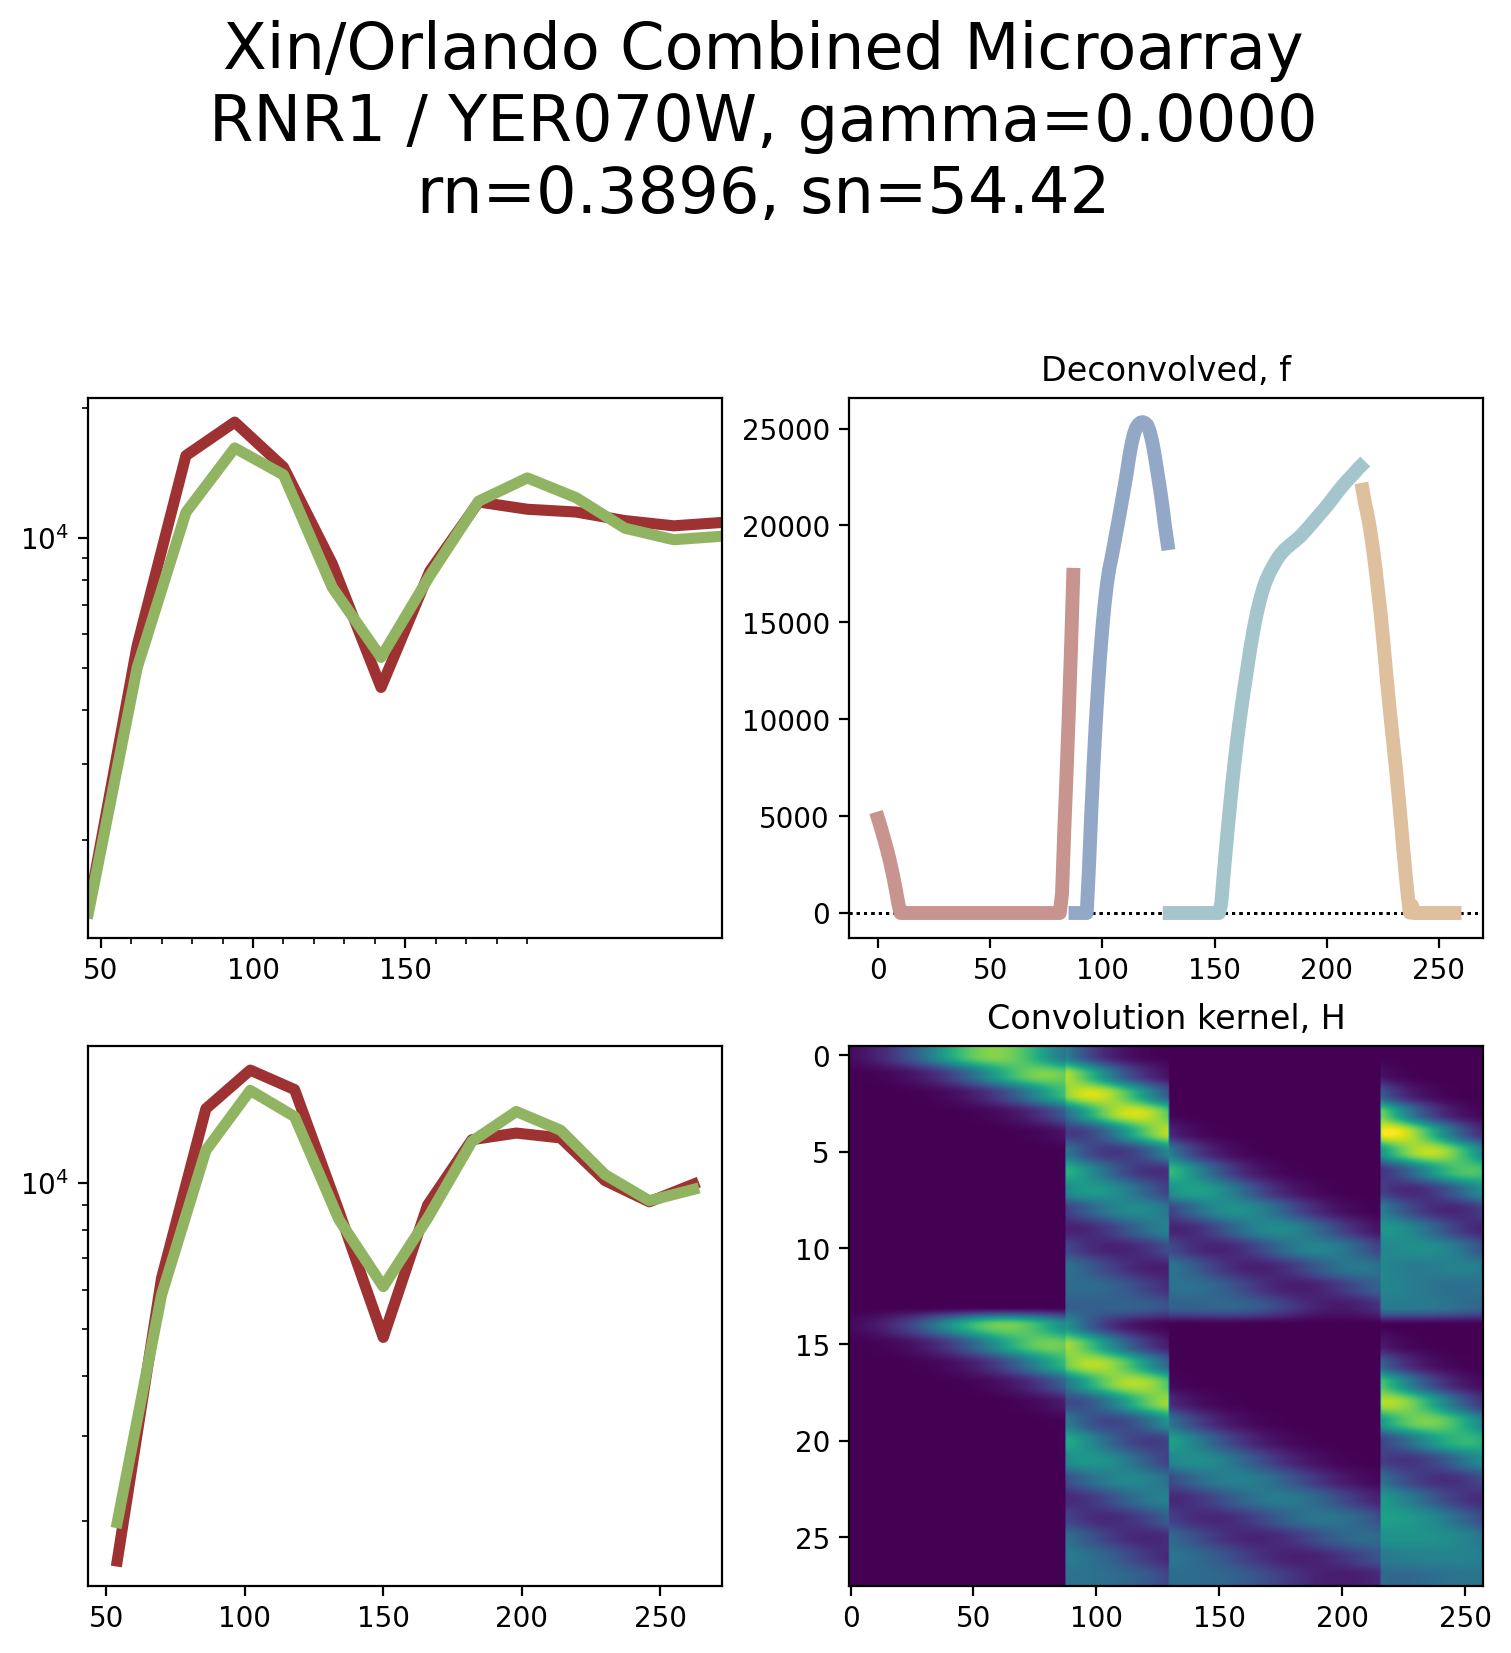

In [4]:
from src.config import load_xg_gene_expression_config

xg_config = load_xg_gene_expression_config()
xg_model = Model(xg_config, 'RNR1', 0.0)
xg_model.deconvolve()
xg_model.plot_deconvolved_gene(abbreviated=True)
print(f"Gene expression:\n\tMin: {xg_model.g.min():.2f}\n\tMax: {xg_model.g.max():.2f}" )

Gene expression:
	Min: 1018.16
	Max: 1938.37


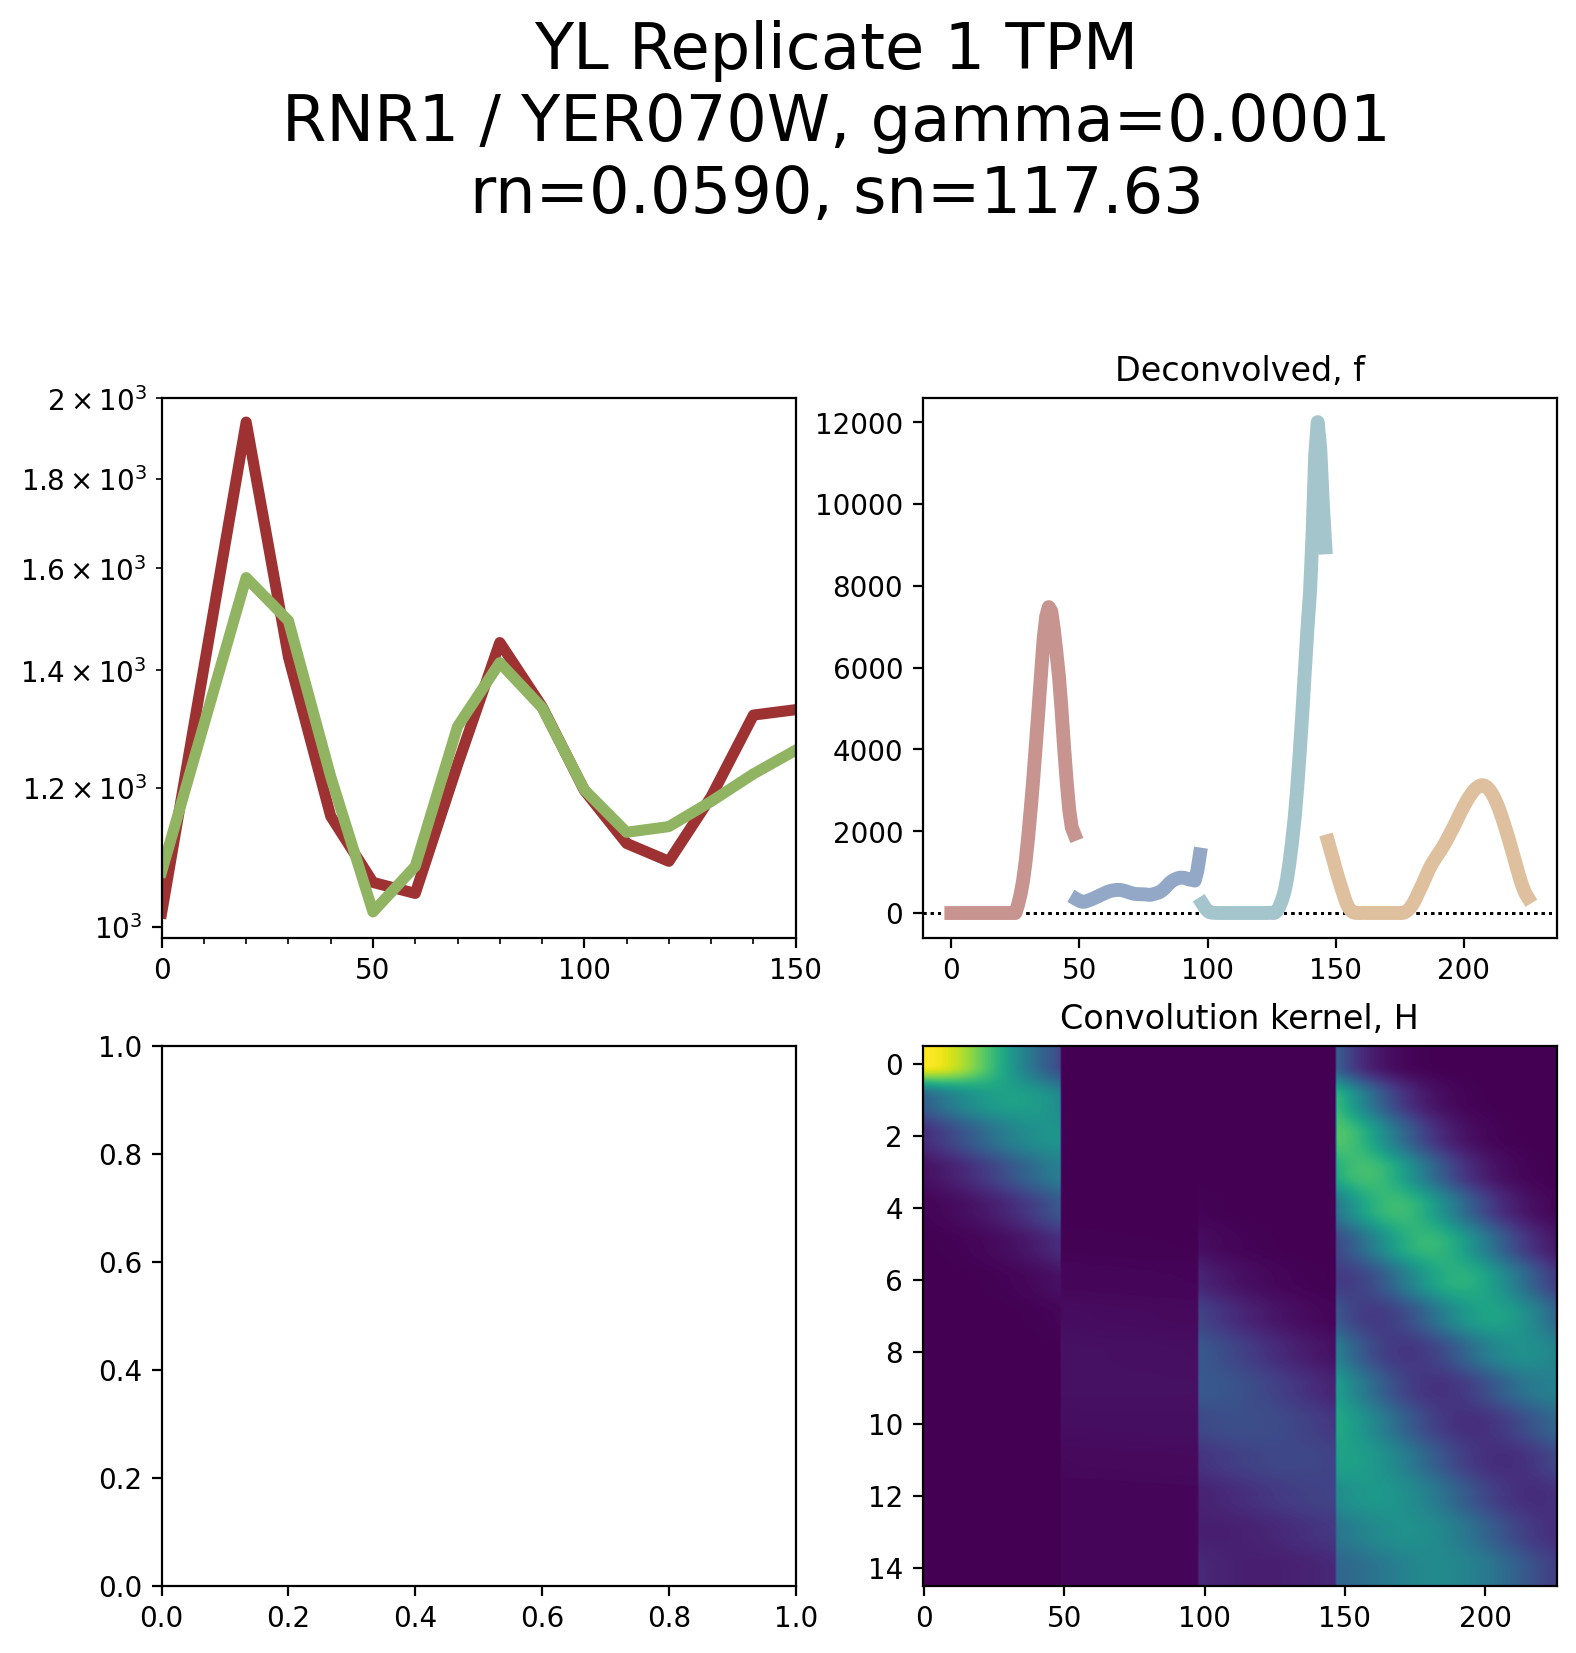

In [5]:
from src.config import load_yl_replicate1_rg1_TPM_config

tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(tpm_config, 'RNR1', 0.0001)

tpm_model.g = tpm_model.g + 1000
tpm_model.g1 = tpm_model.g1 + 1000

tpm_model.deconvolve()
tpm_model.plot_deconvolved_gene(abbreviated=True)
print(f"Gene expression:\n\tMin: {tpm_model.g.min():.2f}\n\tMax: {tpm_model.g.max():.2f}" )

In [6]:
import os
import glob

# Next let's load the gene expresion PTRs
pattern = os.path.join('output/deconvolve_gene_expression_combined_vst_2024_01_16/', '*meta*')
vst_meta_files = glob.glob(pattern)


In [7]:
from cc_src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
vst_results = genes[[]].copy()
vst_results['rn'] = None
vst_results['sn'] = None
vst_results['gm'] = None
vst_results['ptr'] = None

for vst_file in vst_meta_files:
    meta_df = pd.read_csv(vst_file).rename(columns={'Unnamed: 0':
        'orf_name'}).set_index('orf_name')
    orf_name = meta_df.index
    vst_results.loc[orf_name] = meta_df

Text(0.5, 0.98, 'RNA-seq VST\nFit vs Max/Min Gene Expression')

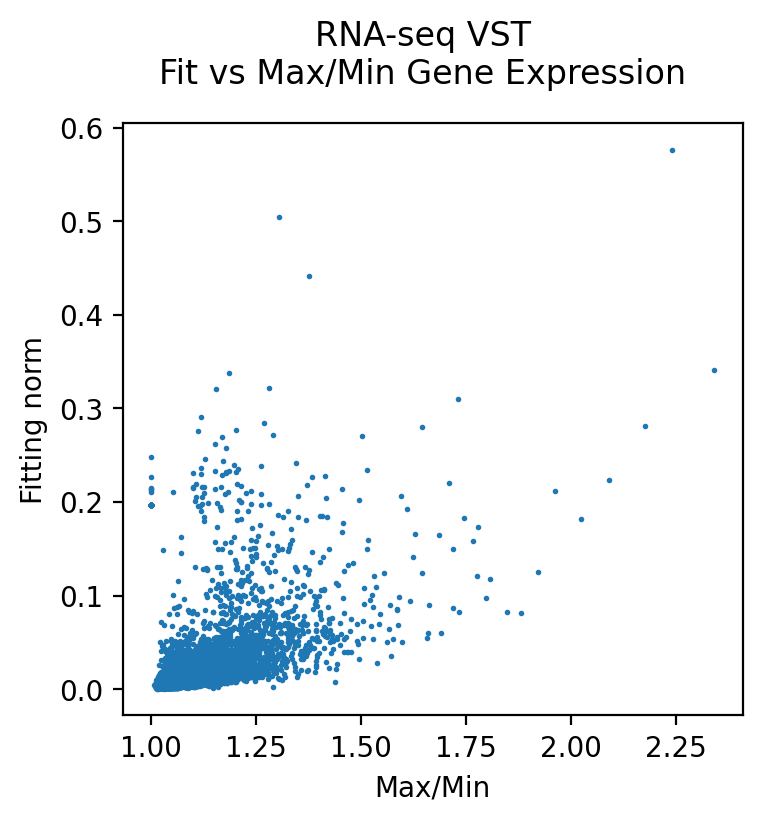

In [8]:
# My next hunch is that the ratio between max and min gene expression 
# affects the quality of the deconvolution
# let's plot the max/min vs rn


vst_diff_vs_rn_df = norm_analysis.vst_diff.join(vst_results)
vst_diff_vs_rn_df['max_min_ratio'] = vst_diff_vs_rn_df['max'] / vst_diff_vs_rn_df['min']

plt.figure(figsize=(4, 4))
plt.subplots_adjust(top=0.85)
plt.scatter(vst_diff_vs_rn_df['max_min_ratio'], vst_diff_vs_rn_df['rn'], s=1)
plt.xlabel('Max/Min')
plt.ylabel('Fitting norm')
plt.suptitle("RNA-seq VST\nFit vs Max/Min Gene Expression")

In [9]:
# Next let's load the gene expresion PTRs
pattern = os.path.join('output/deconvolve_gene_expression_replicate1_2024_01_15/', '*meta*')
rep1_tpm_meta_files = glob.glob(pattern)

from cc_src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
tpm_results = genes[[]].copy()
tpm_results['rn'] = None
tpm_results['sn'] = None
tpm_results['gm'] = None
tpm_results['ptr'] = None

for tpm_meta_file in rep1_tpm_meta_files:
    meta_df = pd.read_csv(tpm_meta_file).rename(columns={'Unnamed: 0':
        'orf_name'}).set_index('orf_name')
    orf_name = meta_df.index
    tpm_results.loc[orf_name] = meta_df
tpm_results.head(2)

,rn,sn,gm,ptr
orf_name,,,,
YAL068C,inf,20.2587,0.004,0.0903
YAL067W-A,inf,inf,0.004,1.0117


Text(0.5, 0.98, 'RNA-seq TPM\nFit vs Max/Min Gene Expression')

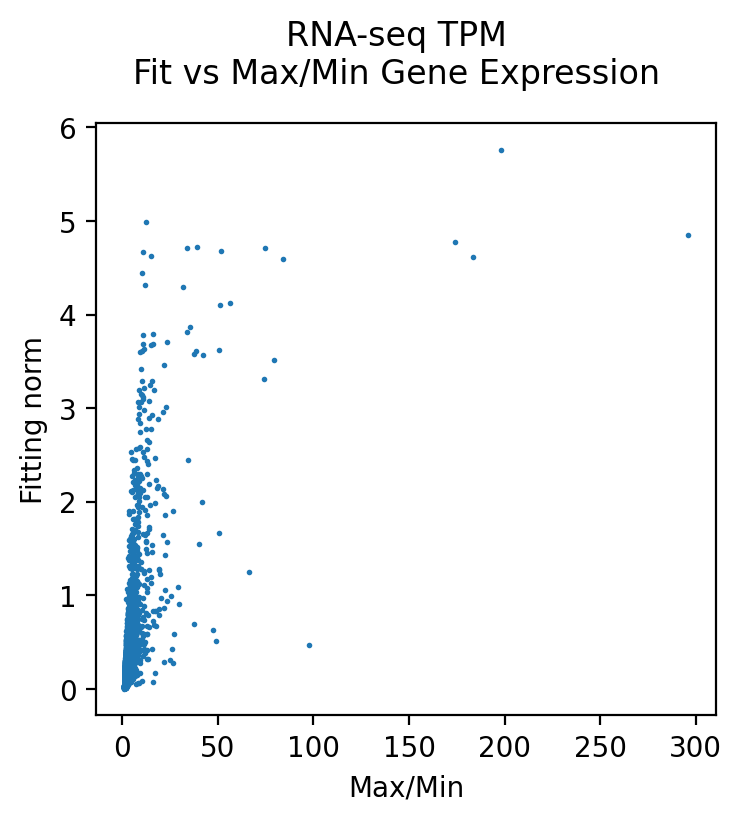

In [10]:
# My next hunch is that the ratio between max and min gene expression 
# affects the quality of the deconvolution
# let's plot the max/min vs rn

tpm_diff_vs_rn_df = norm_analysis.tpm_diff.join(tpm_results)
tpm_diff_vs_rn_df['max_min_ratio'] = tpm_diff_vs_rn_df['max'] / tpm_diff_vs_rn_df['min']

plt.figure(figsize=(4, 4))
plt.subplots_adjust(top=0.85)
plt.scatter(tpm_diff_vs_rn_df['max_min_ratio'], tpm_diff_vs_rn_df['rn'], s=1)
plt.xlabel('Max/Min')
plt.ylabel('Fitting norm')
plt.suptitle("RNA-seq TPM\nFit vs Max/Min Gene Expression")

Gene expression:
	Min: 1006.65
	Max: 1049.82


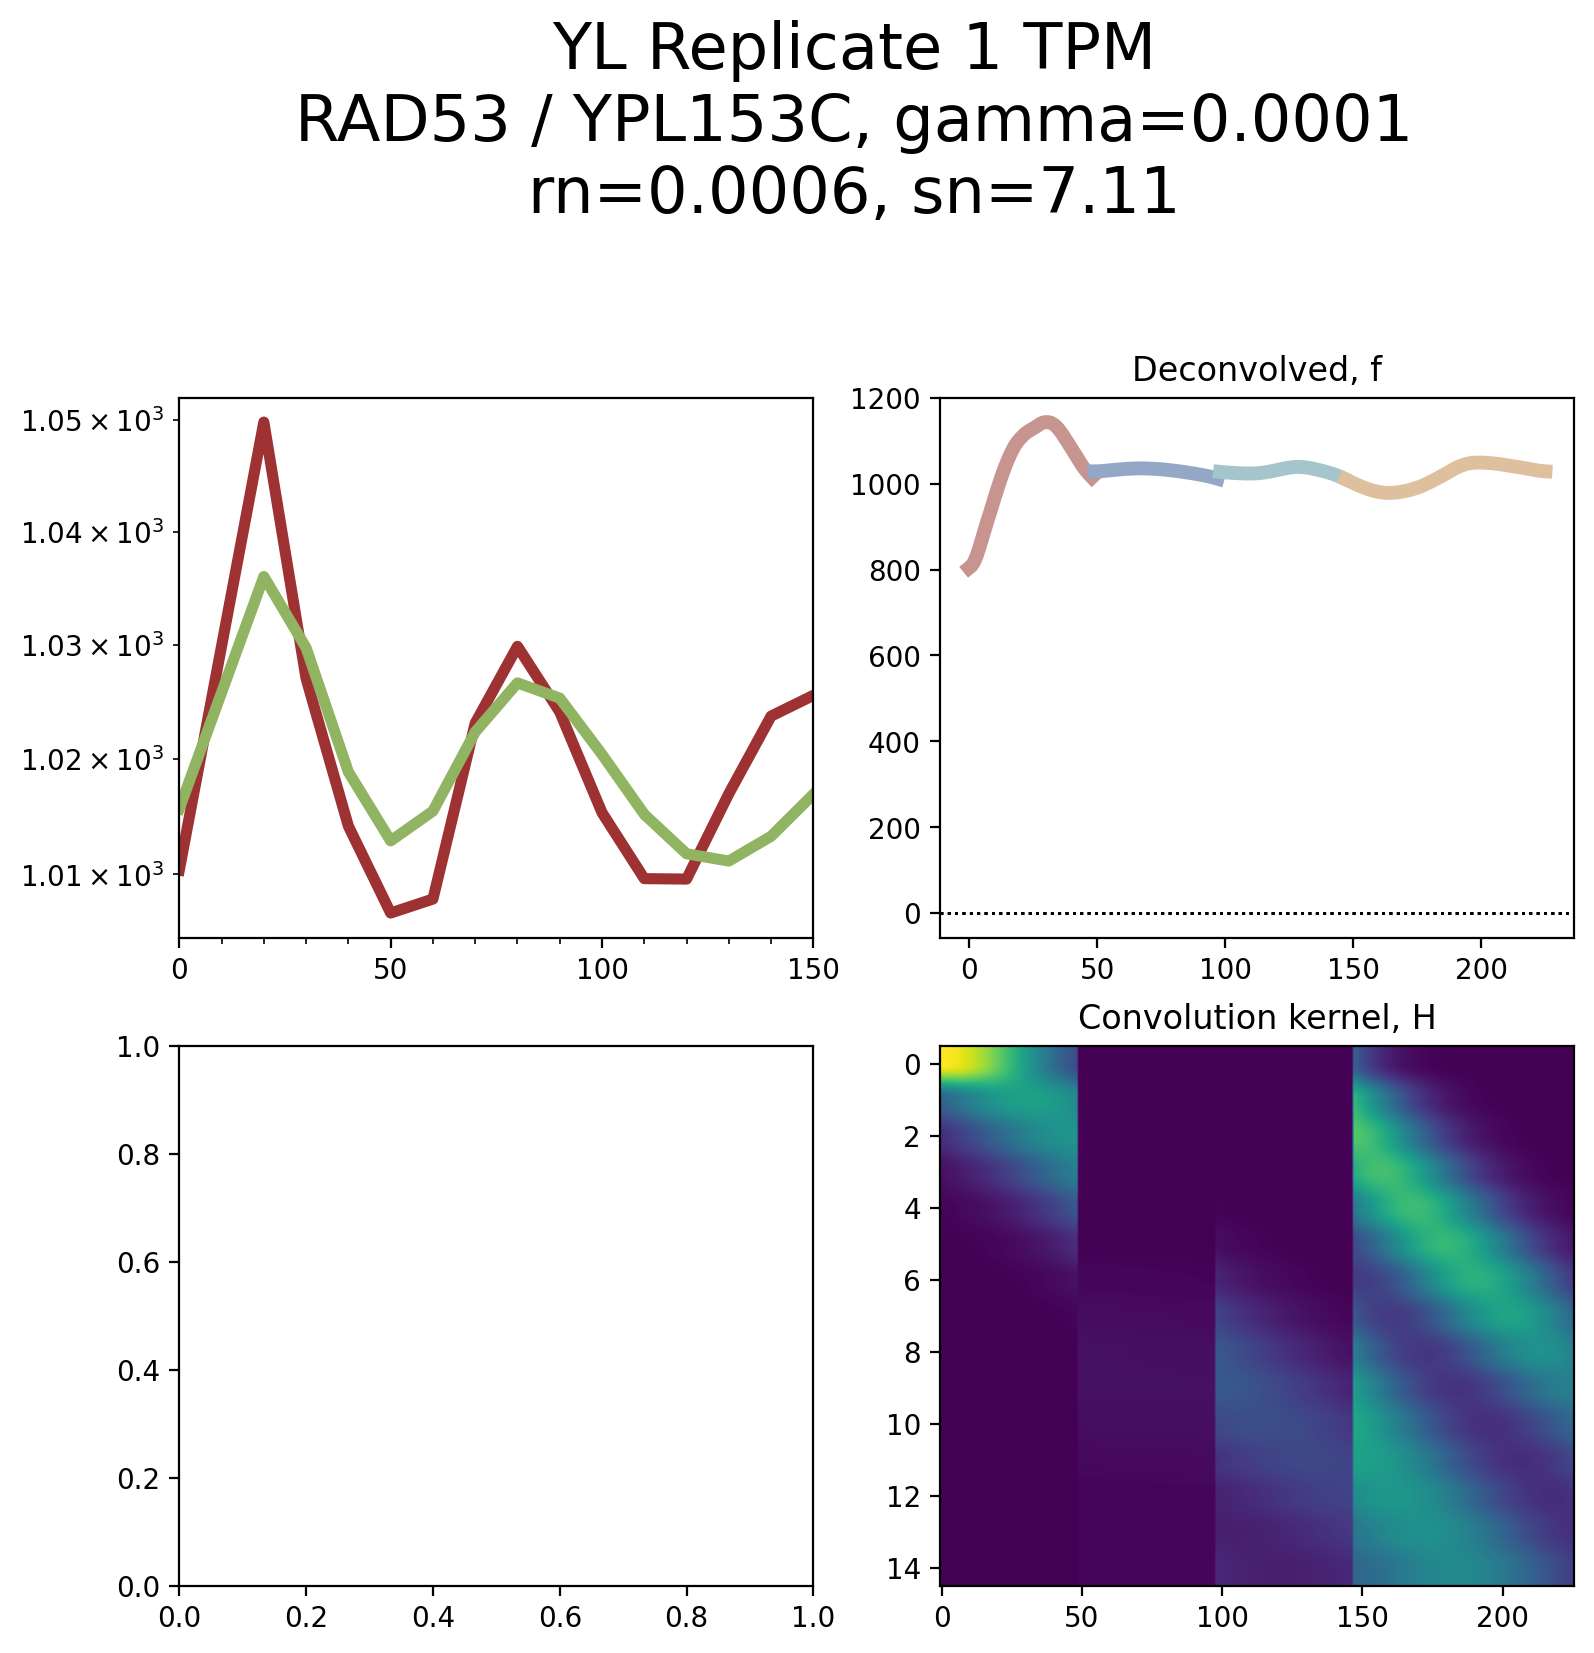

In [11]:
from src.config import load_yl_replicate1_rg1_TPM_config

tpm_config = load_yl_replicate1_rg1_TPM_config()
tpm_model = Model(tpm_config, 'RAD53', 0.0001)

tpm_model.g = tpm_model.g + 1000
tpm_model.g1 = tpm_model.g1 + 1000

tpm_model.deconvolve()
tpm_model.plot_deconvolved_gene(abbreviated=True)
print(f"Gene expression:\n\tMin: {tpm_model.g.min():.2f}\n\tMax: {tpm_model.g.max():.2f}" )

# Positive Control Examples

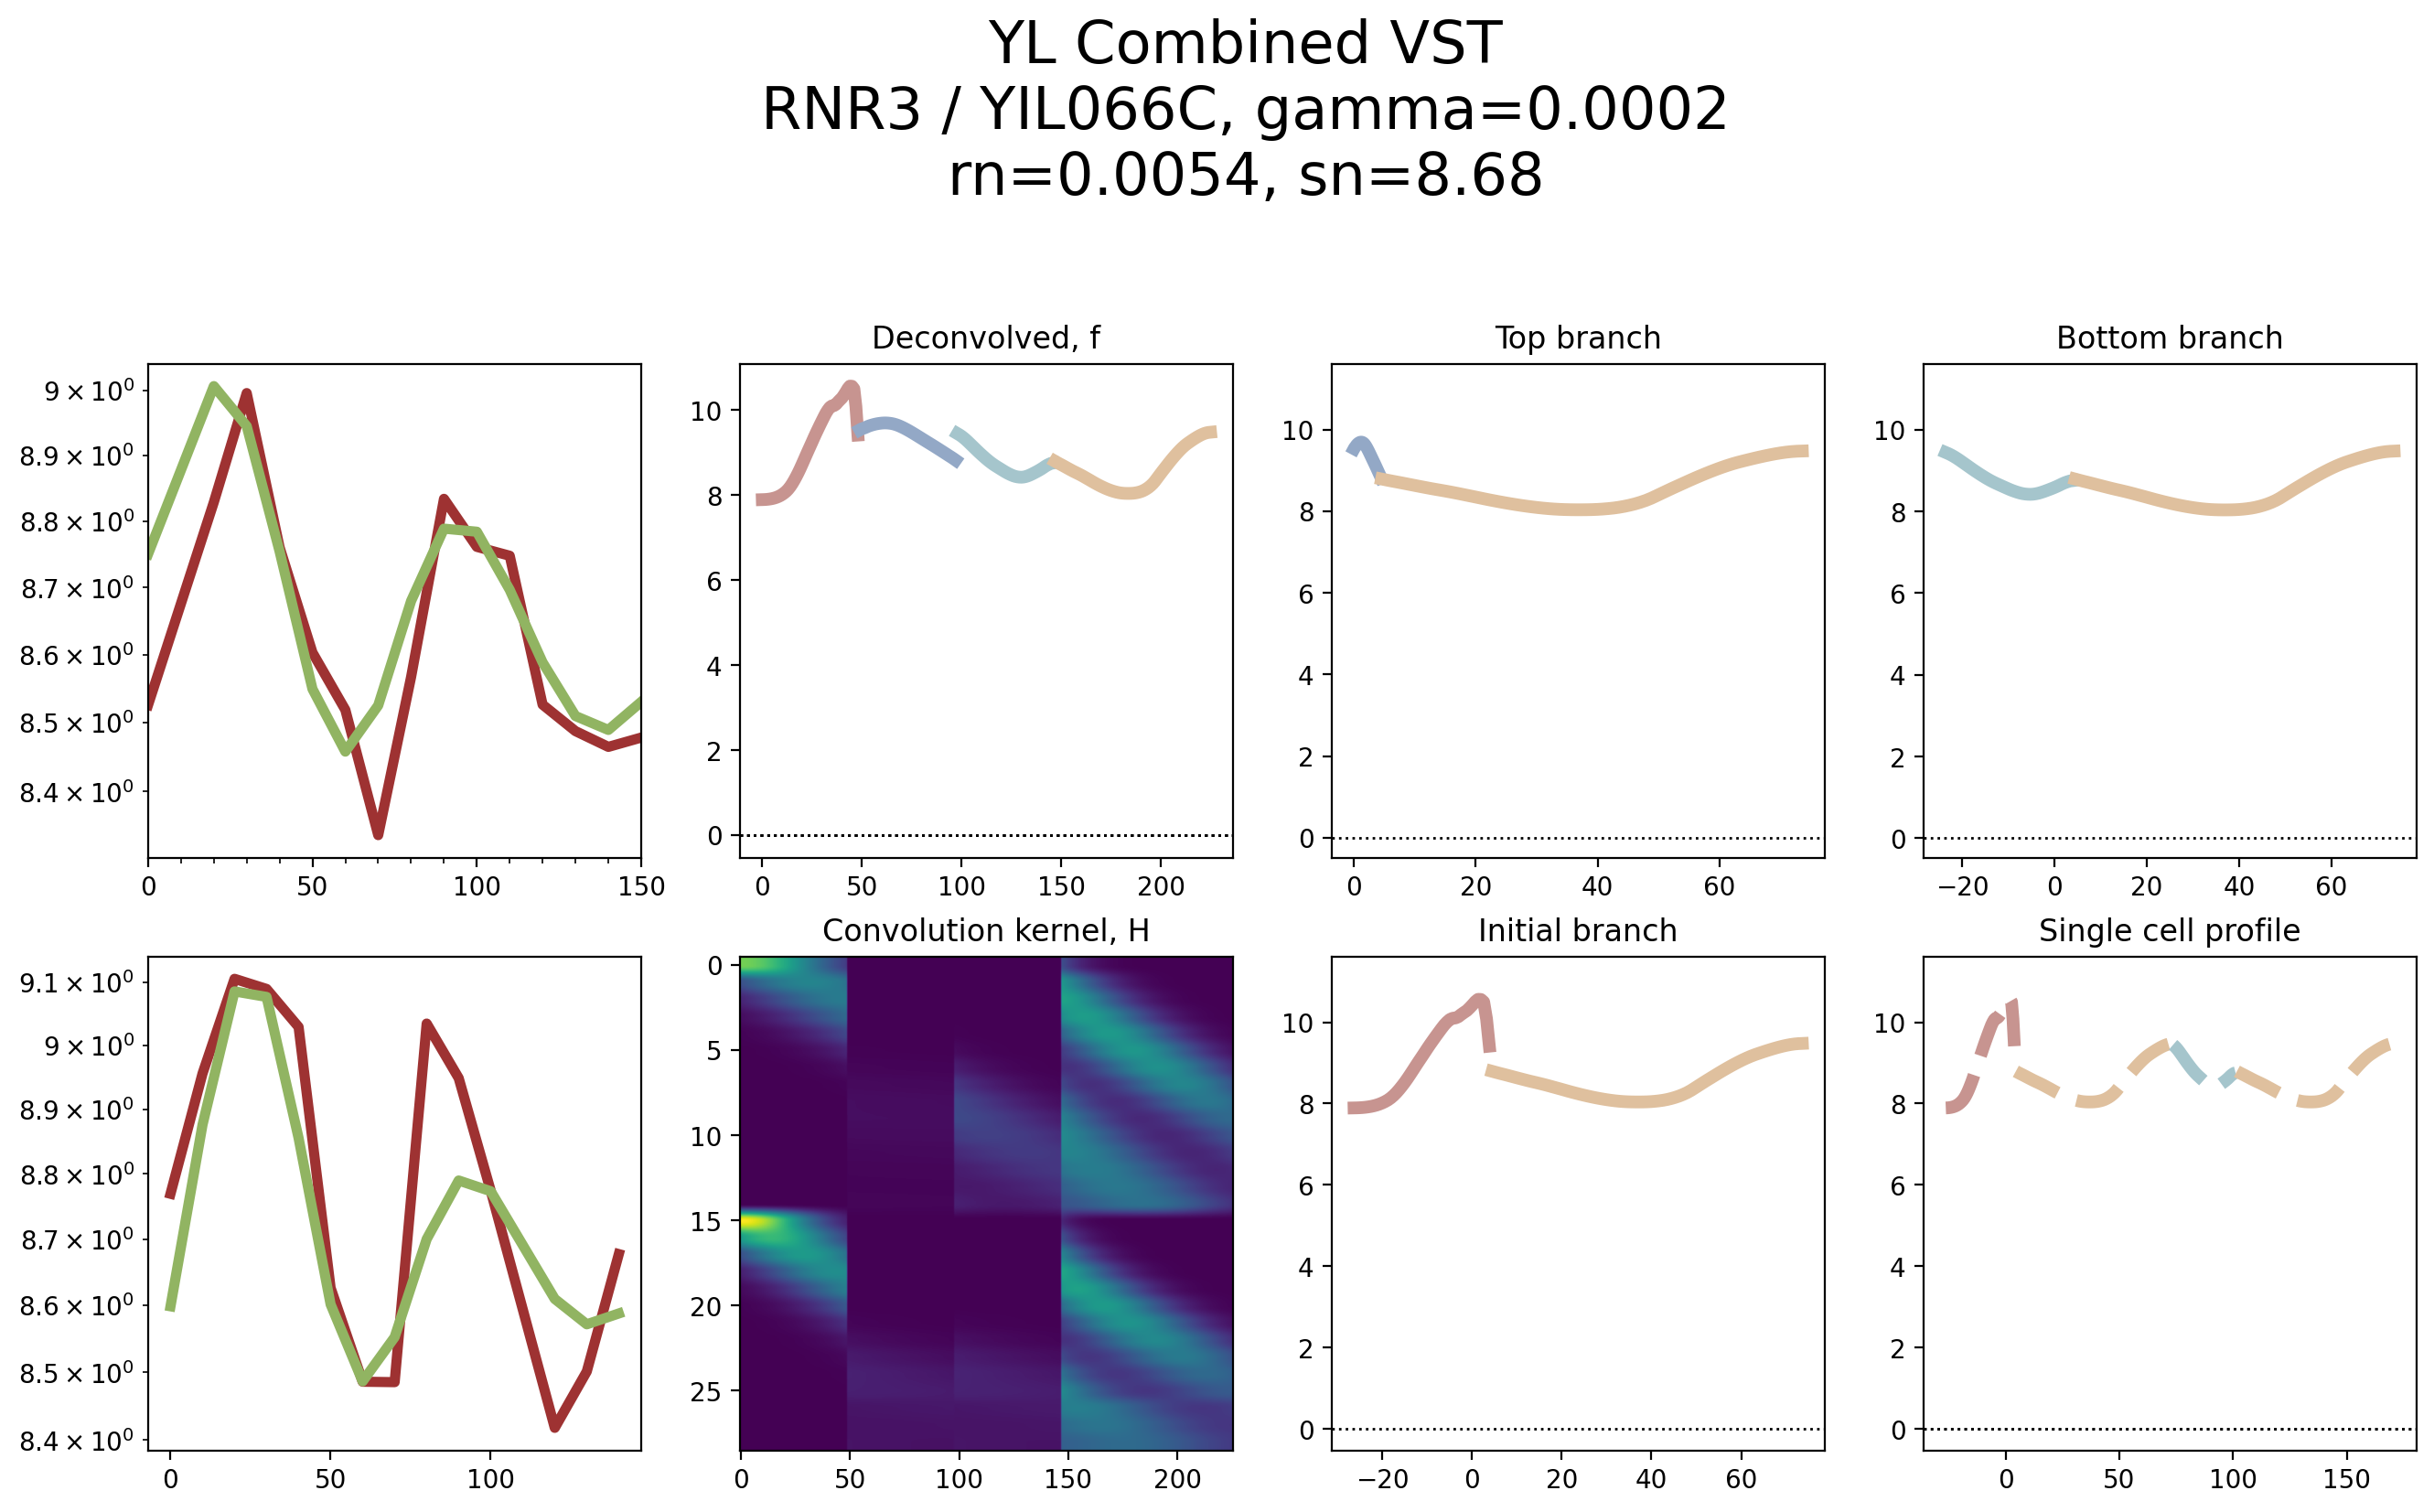

In [12]:

vst_model = Model(rep1_vst_config, 'RNR3', 0.0002)
vst_model.deconvolve()
vst_model.plot_deconvolved_gene(abbreviated=False)


Deconvolving RNR1
findOptimal
  ... base_rn = 0.0659
  ... gamma in [0.0001, 0.0010]
  ...  search left, rn_goal = 0.0725, rate = 10.0
  ...  search right, rn_goal = 0.3859, rate = 485.3
  ... rn range: [0.0810, 0.1173]
  ... search gamma in [0.0001 0.0010] for elbow
  ...   gamma = 0.0001, rn = 0.08102, sn = 60.4
  ...   gamma = 0.00019, rn = 0.08602, sn = 50.36
  ...   gamma = 0.00028, rn = 0.09073, sn = 42.74
  ...   gamma = 0.00037, rn = 0.0959, sn = 36.02
  ...   gamma = 0.00046, rn = 0.09899, sn = 33.98
  ...   gamma = 0.00055, rn = 0.1012, sn = 33.01
  ...   gamma = 0.00064, rn = 0.1034, sn = 32.01
  ...   gamma = 0.00073, rn = 0.1085, sn = 28.41
  ...   gamma = 0.00082, rn = 0.1114, sn = 25.43
  ...   gamma = 0.00091, rn = 0.1143, sn = 24.43
  ...   gamma = 0.001, rn = 0.1173, sn = 23.49
  ...   gamma = 0.00109, rn = 0.1198, sn = 22.71
The x_grad1 is: [0.00499524 0.00485639 0.00494399 0.00412875 0.00267044 0.00222712
 0.00362998 0.00396845 0.0028836  0.00295118 0.00274647 0.002

  ...   gamma = 0.00046, rn = 0.05228, sn = 23.52
  ...   gamma = 0.00055, rn = 0.05577, sn = 21.48
  ...   gamma = 0.00064, rn = 0.05759, sn = 20.19
  ...   gamma = 0.00073, rn = 0.05935, sn = 19.36
  ...   gamma = 0.00082, rn = 0.06009, sn = 19.06
  ...   gamma = 0.00091, rn = 0.06082, sn = 18.9
  ...   gamma = 0.001, rn = 0.06233, sn = 18.59
  ...   gamma = 0.00109, rn = 0.06388, sn = 18.12
The x_grad1 is: [0.00695185 0.00616434 0.00434605 0.00350622 0.00359533 0.00265368
 0.00178688 0.00125024 0.00073542 0.0011225  0.00153278 0.0015508 ]
The x_grad2 is: [-7.87505531e-04 -1.30289845e-03 -1.32906152e-03 -3.75362373e-04
 -4.26270552e-04 -9.04223988e-04 -7.01720436e-04 -5.25727291e-04
 -6.38671957e-05  3.98676523e-04  2.14148259e-04  1.80227247e-05]
The curvature is: [ 2.70483951e-06  6.65861678e-06  4.52673504e-05  1.52744751e-04
  1.44870121e-04  7.33585966e-05  2.07983985e-04  1.23012596e-03
  8.48751691e-03  2.80923997e-04 -1.59516656e-03 -1.08784956e-03]
YPL153C: ... final gamma =

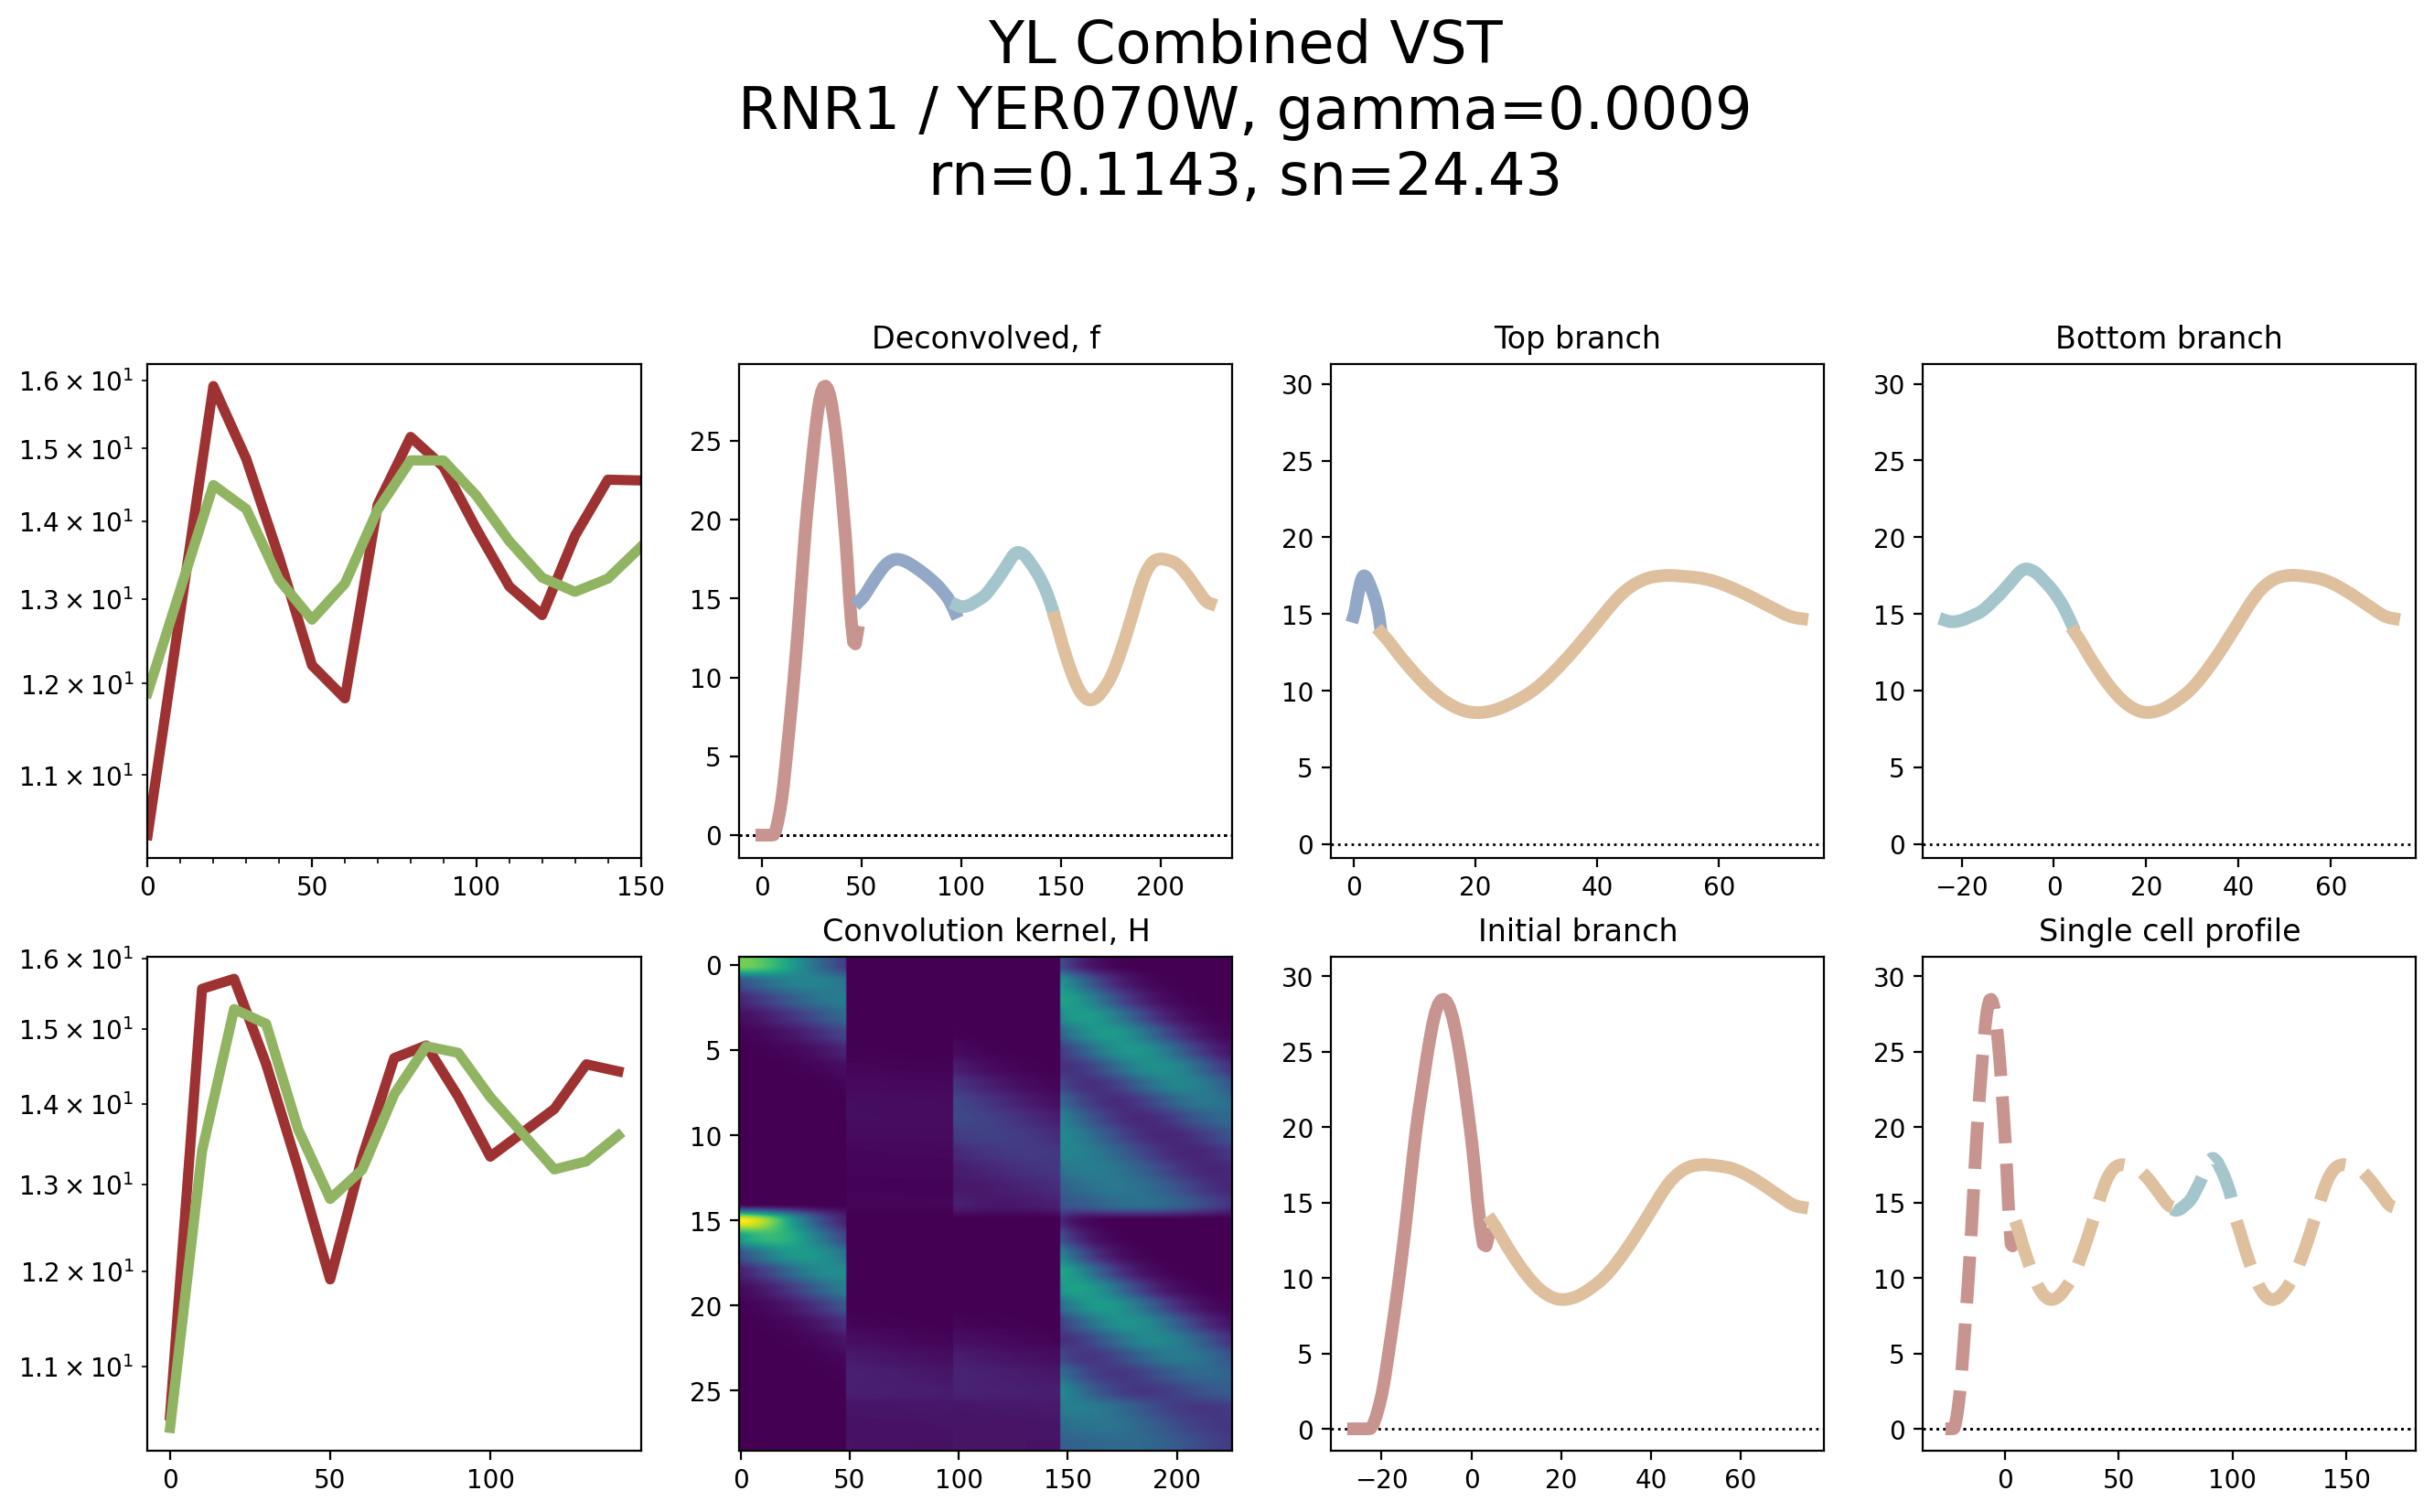

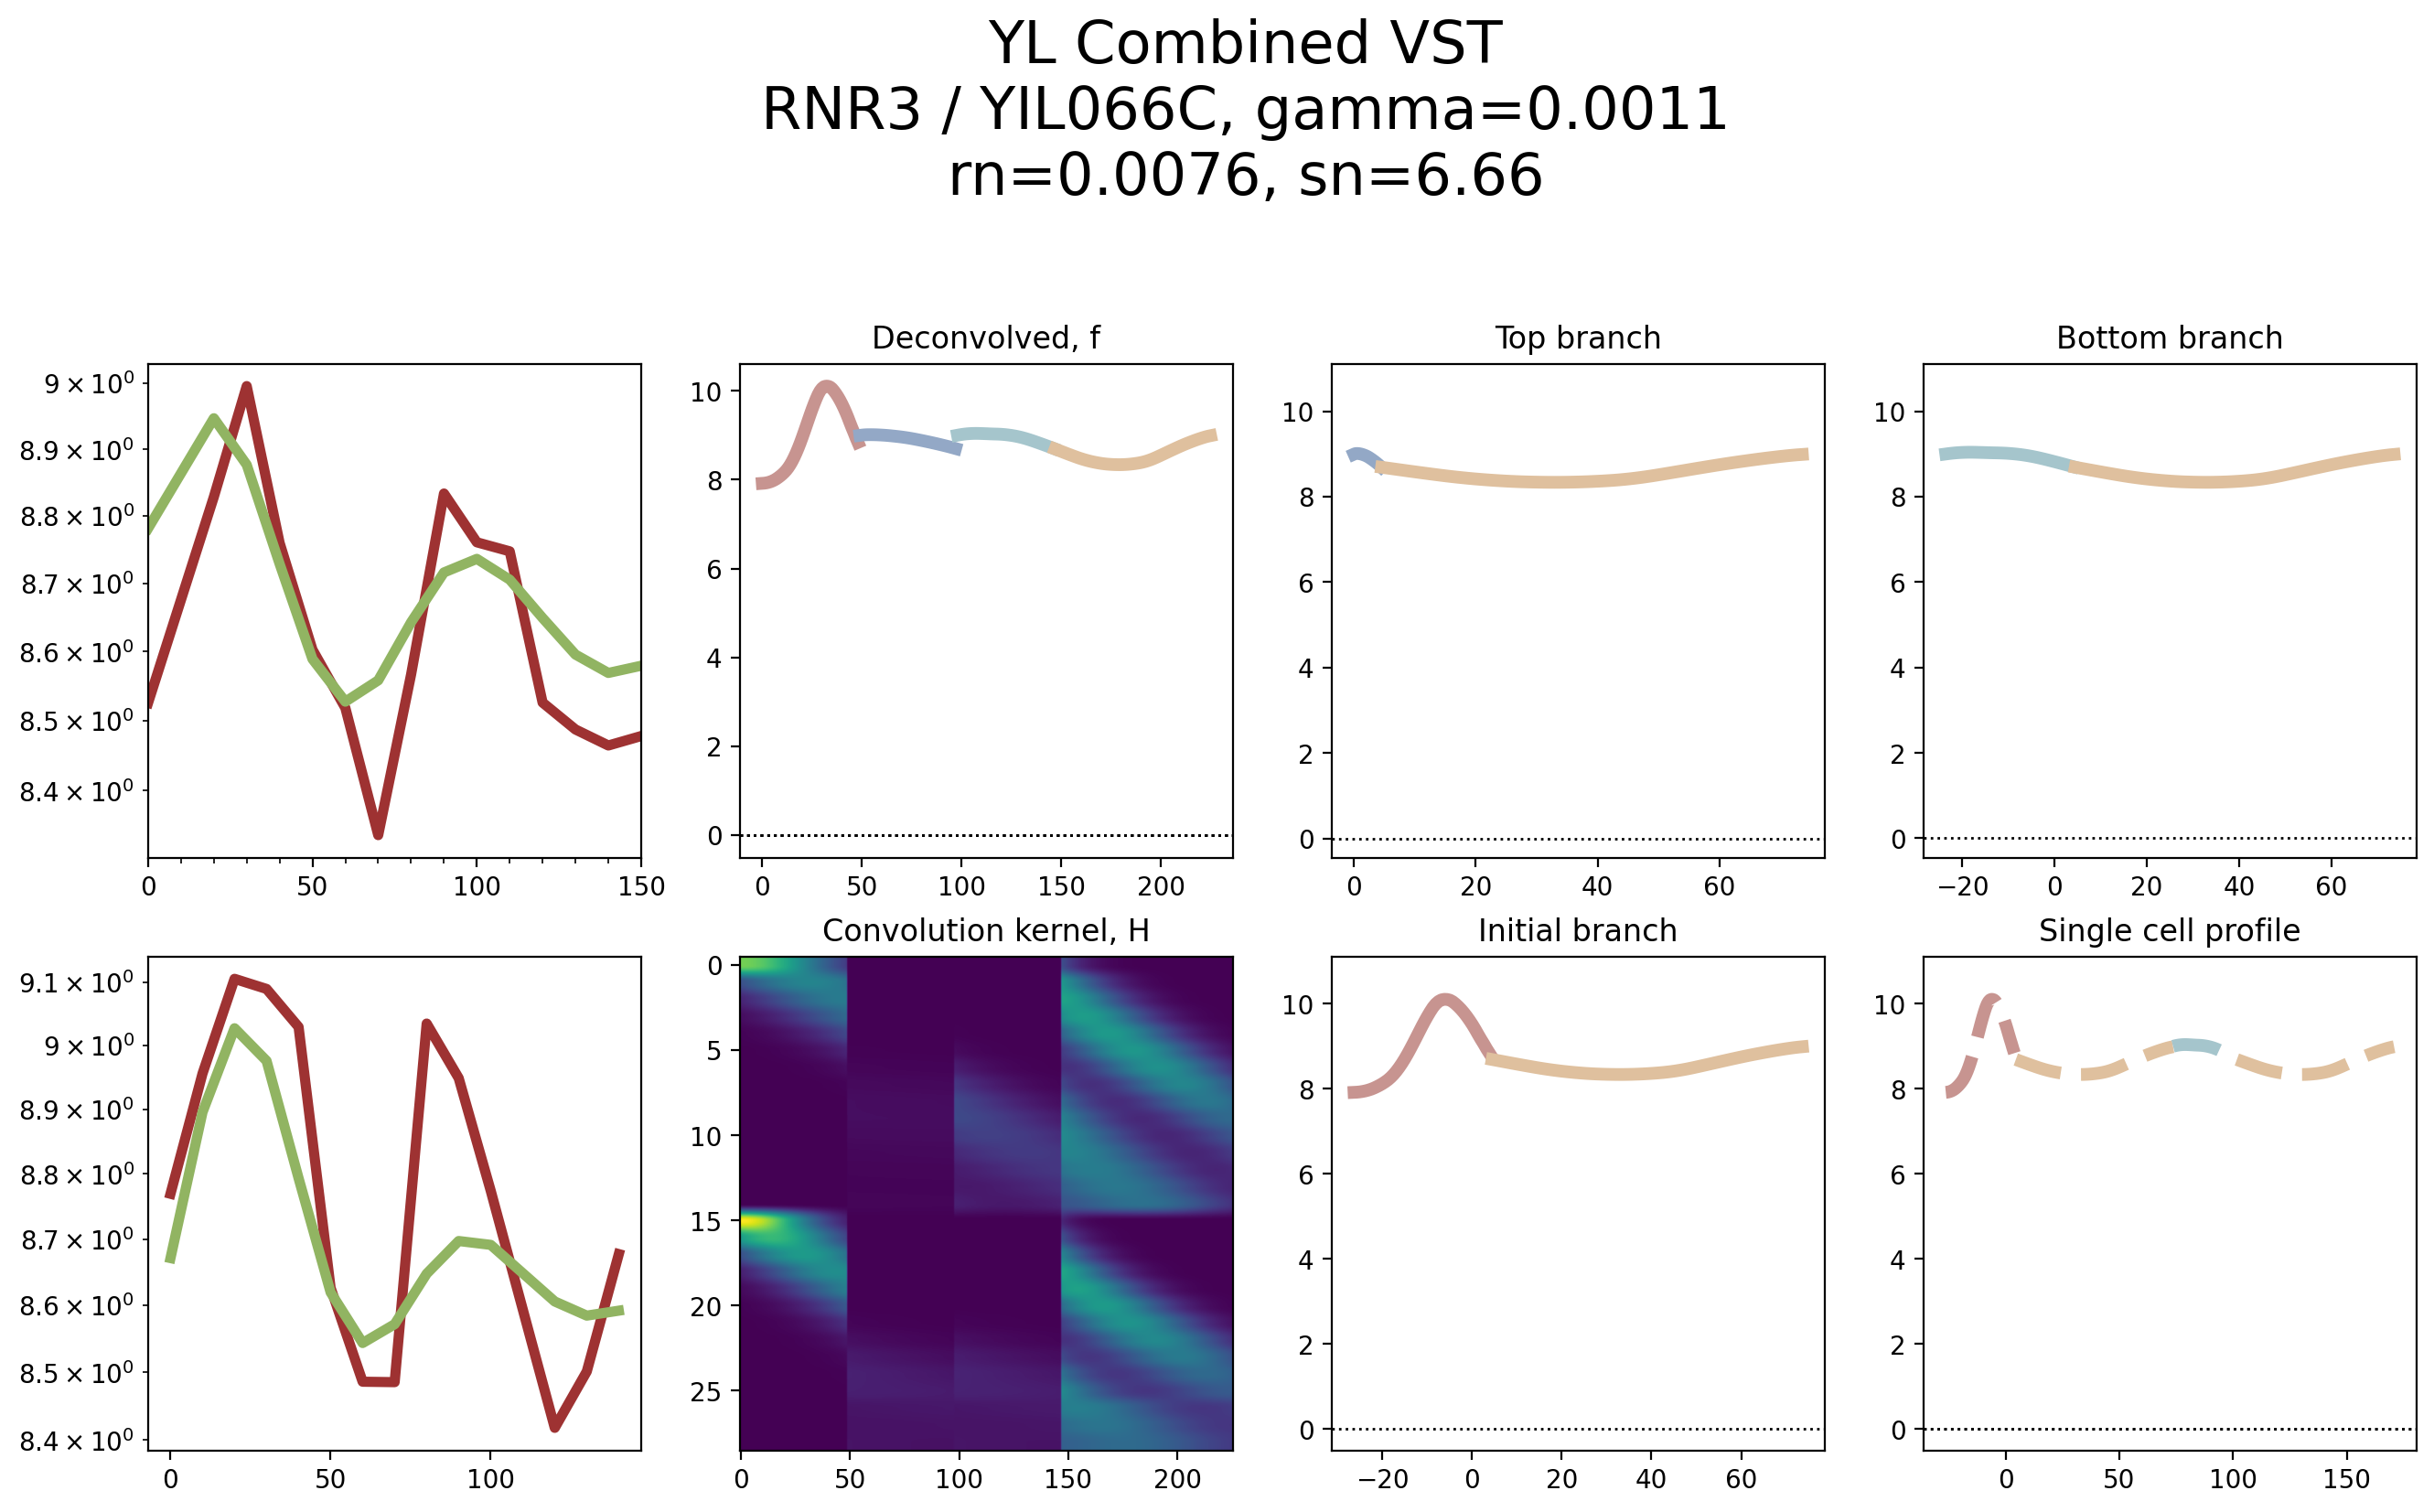

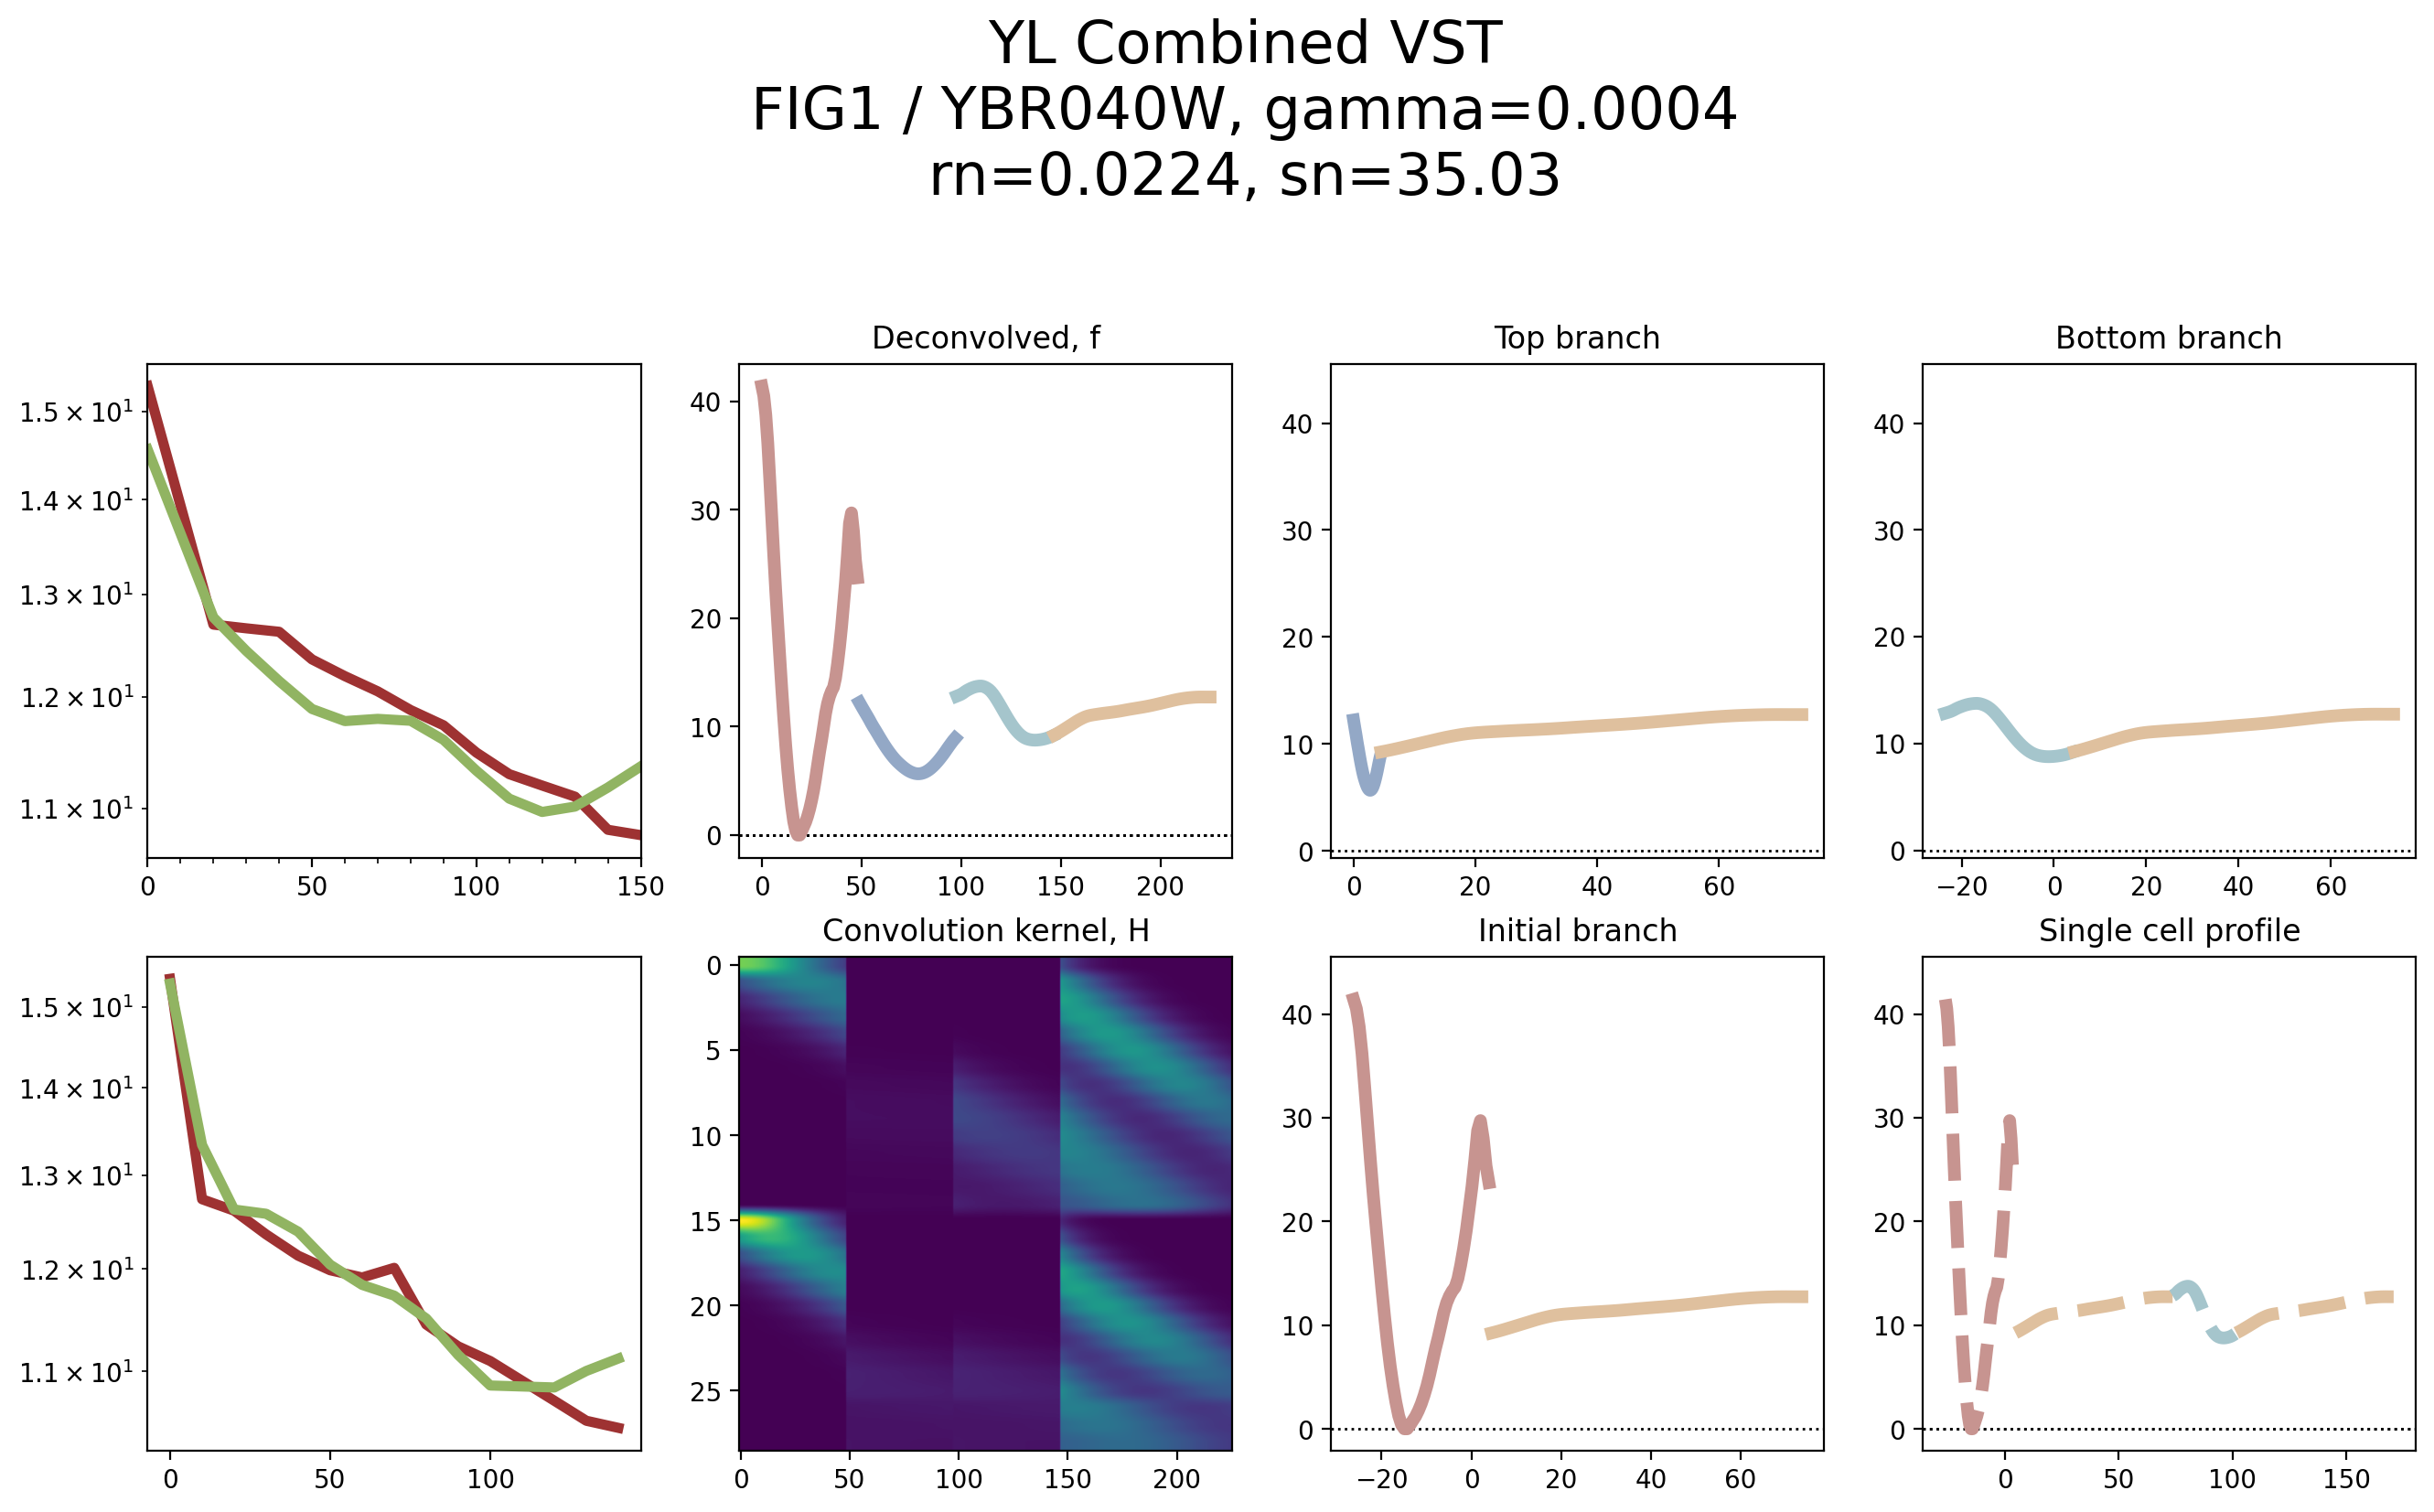

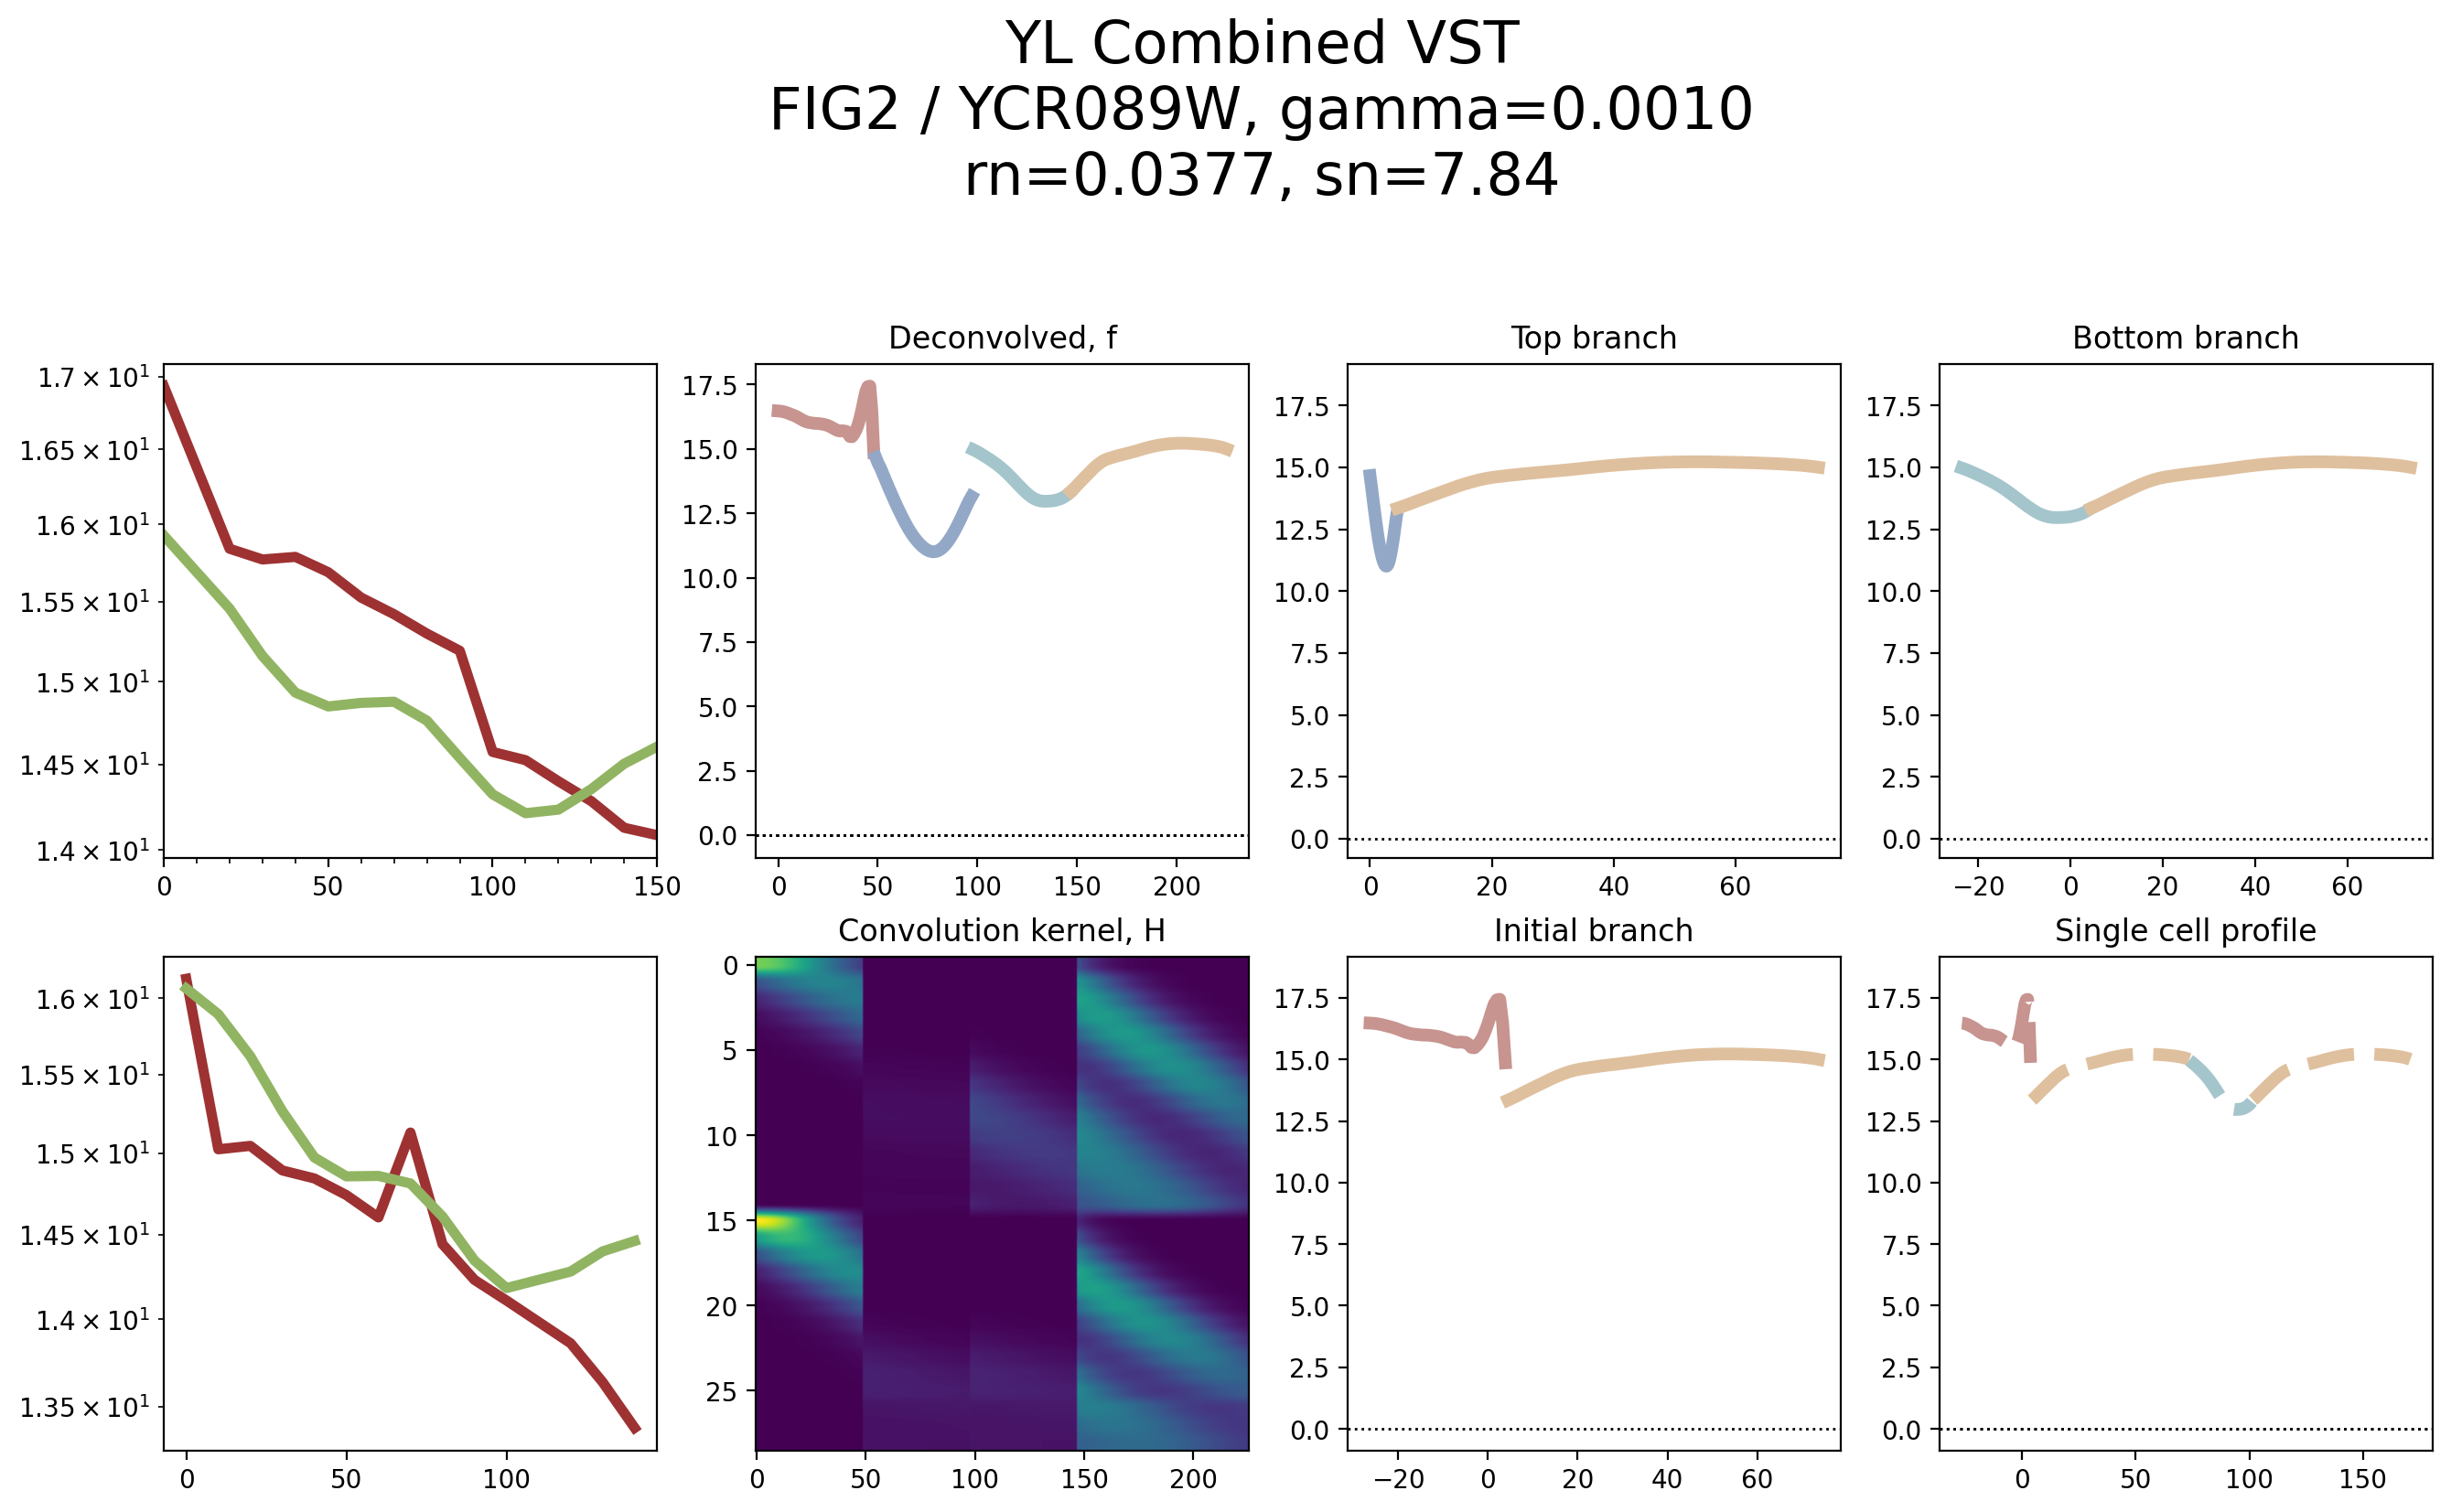

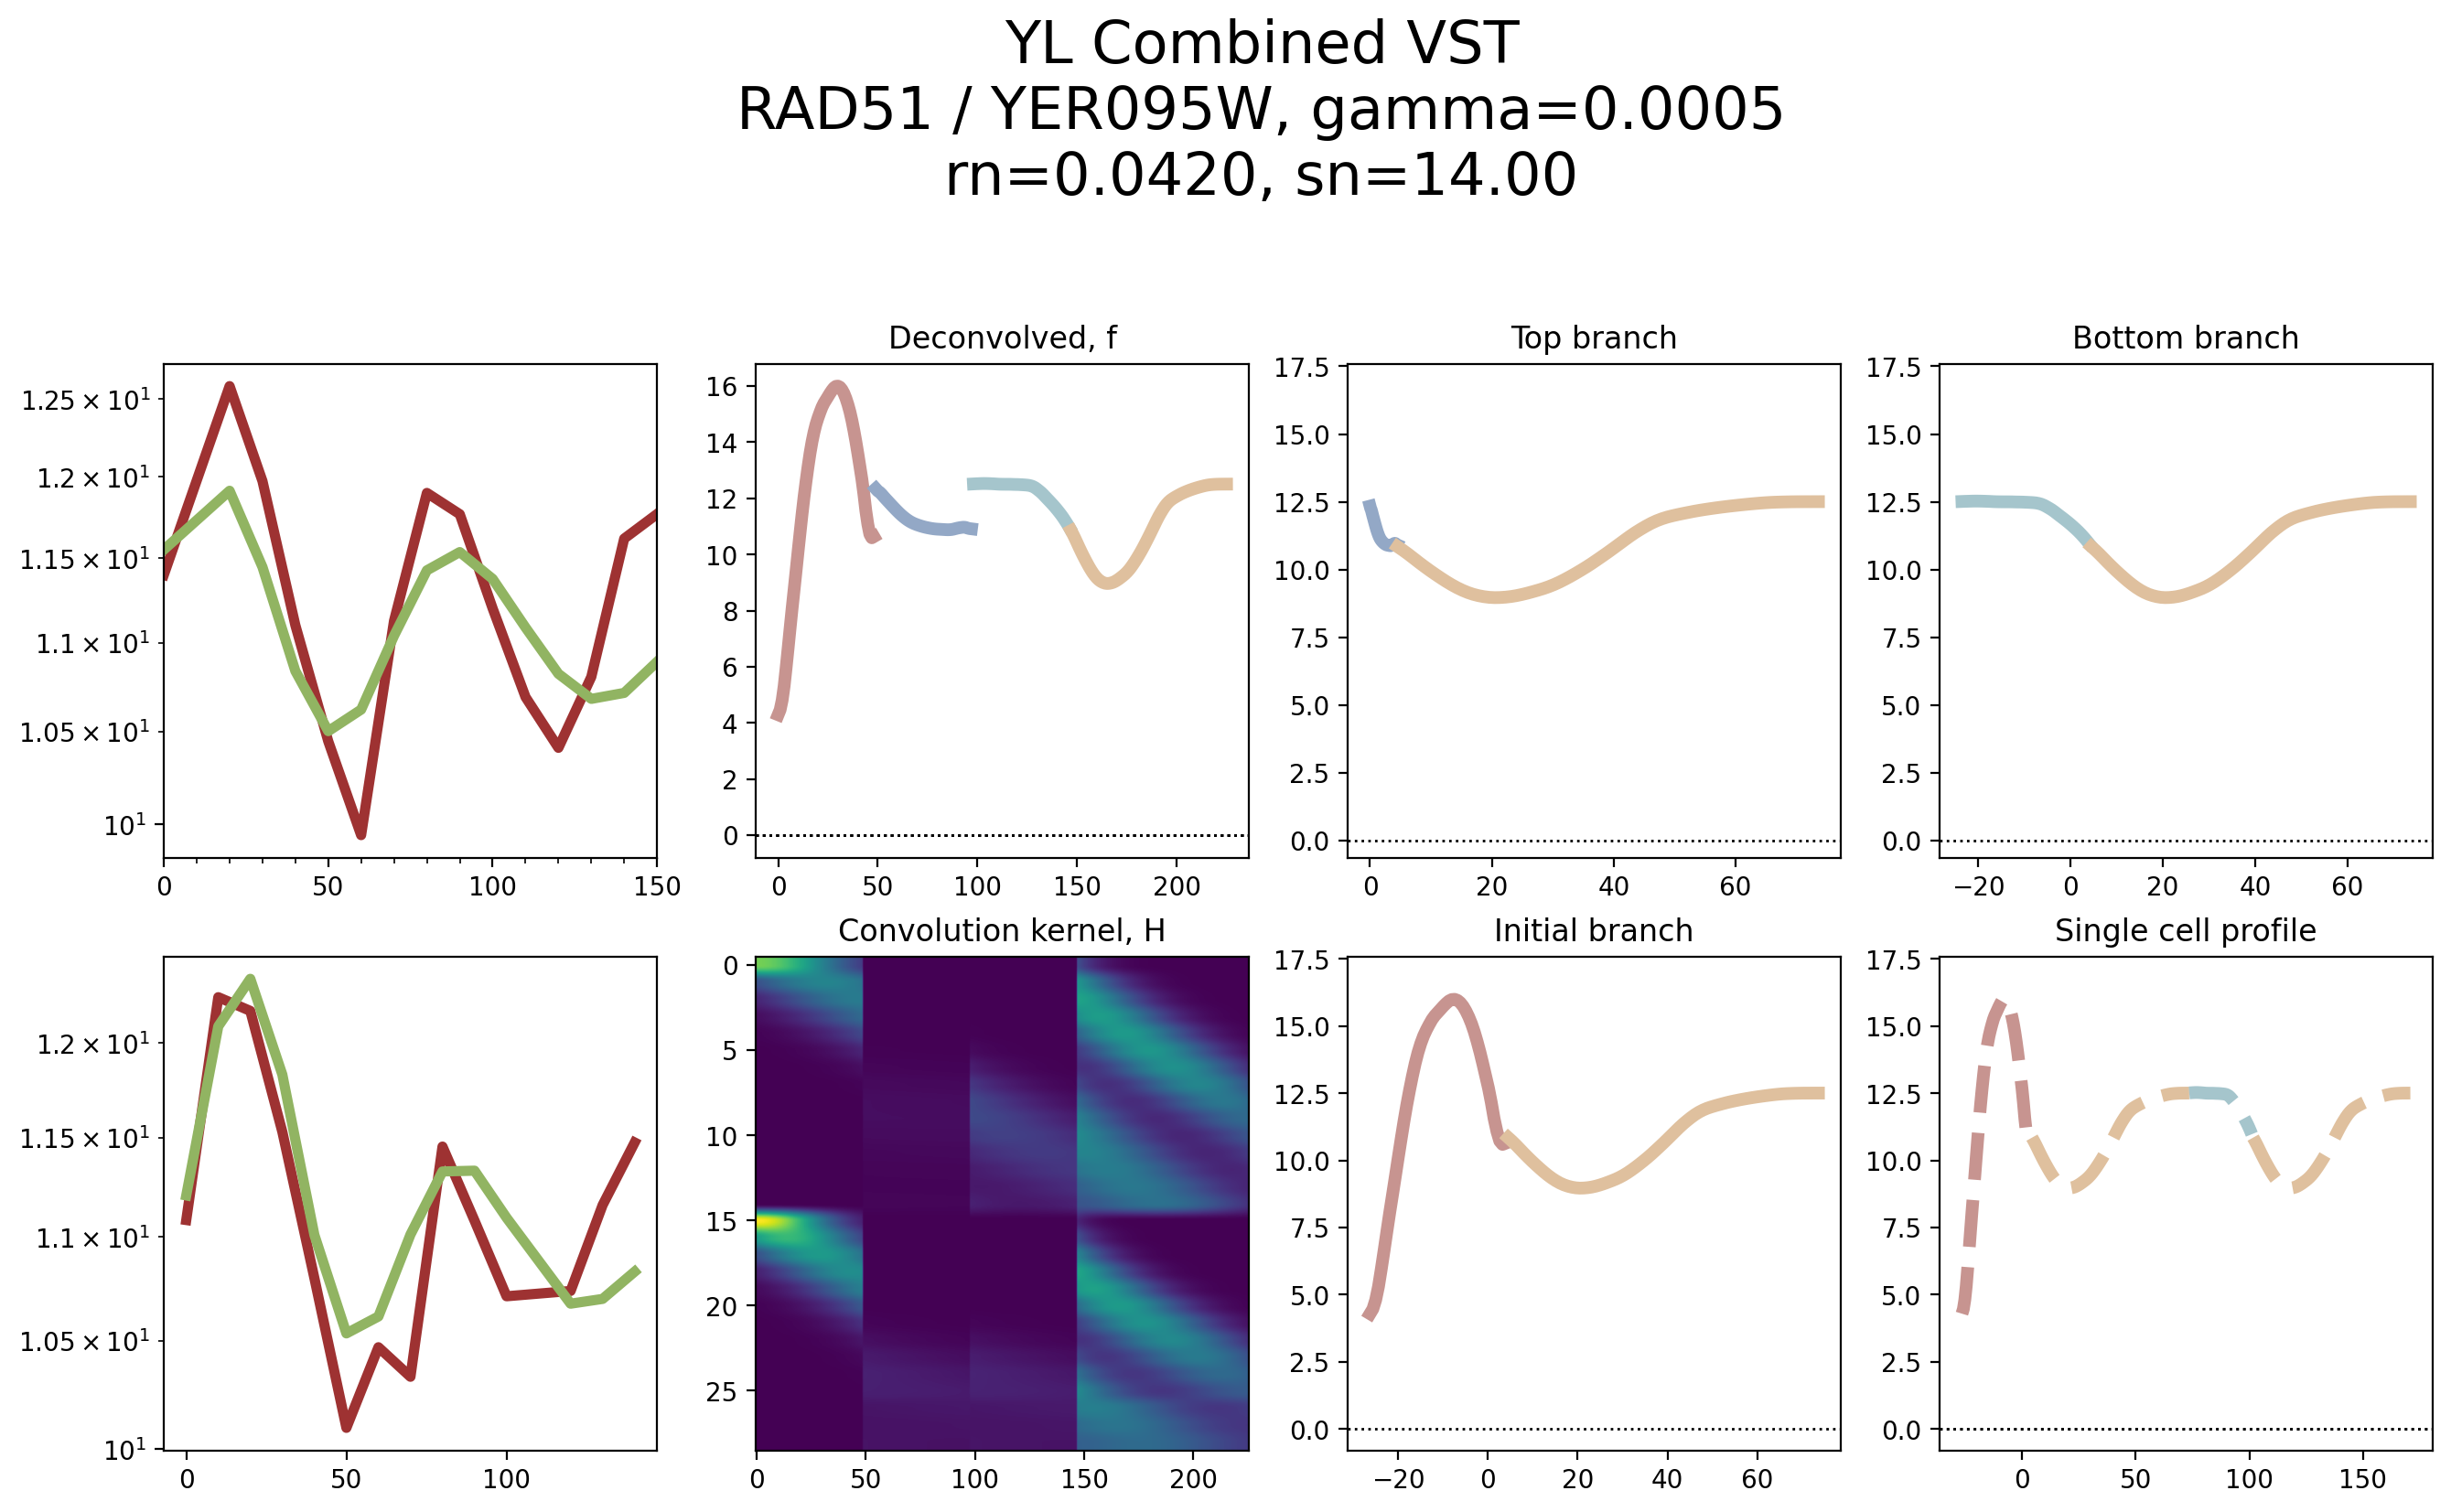

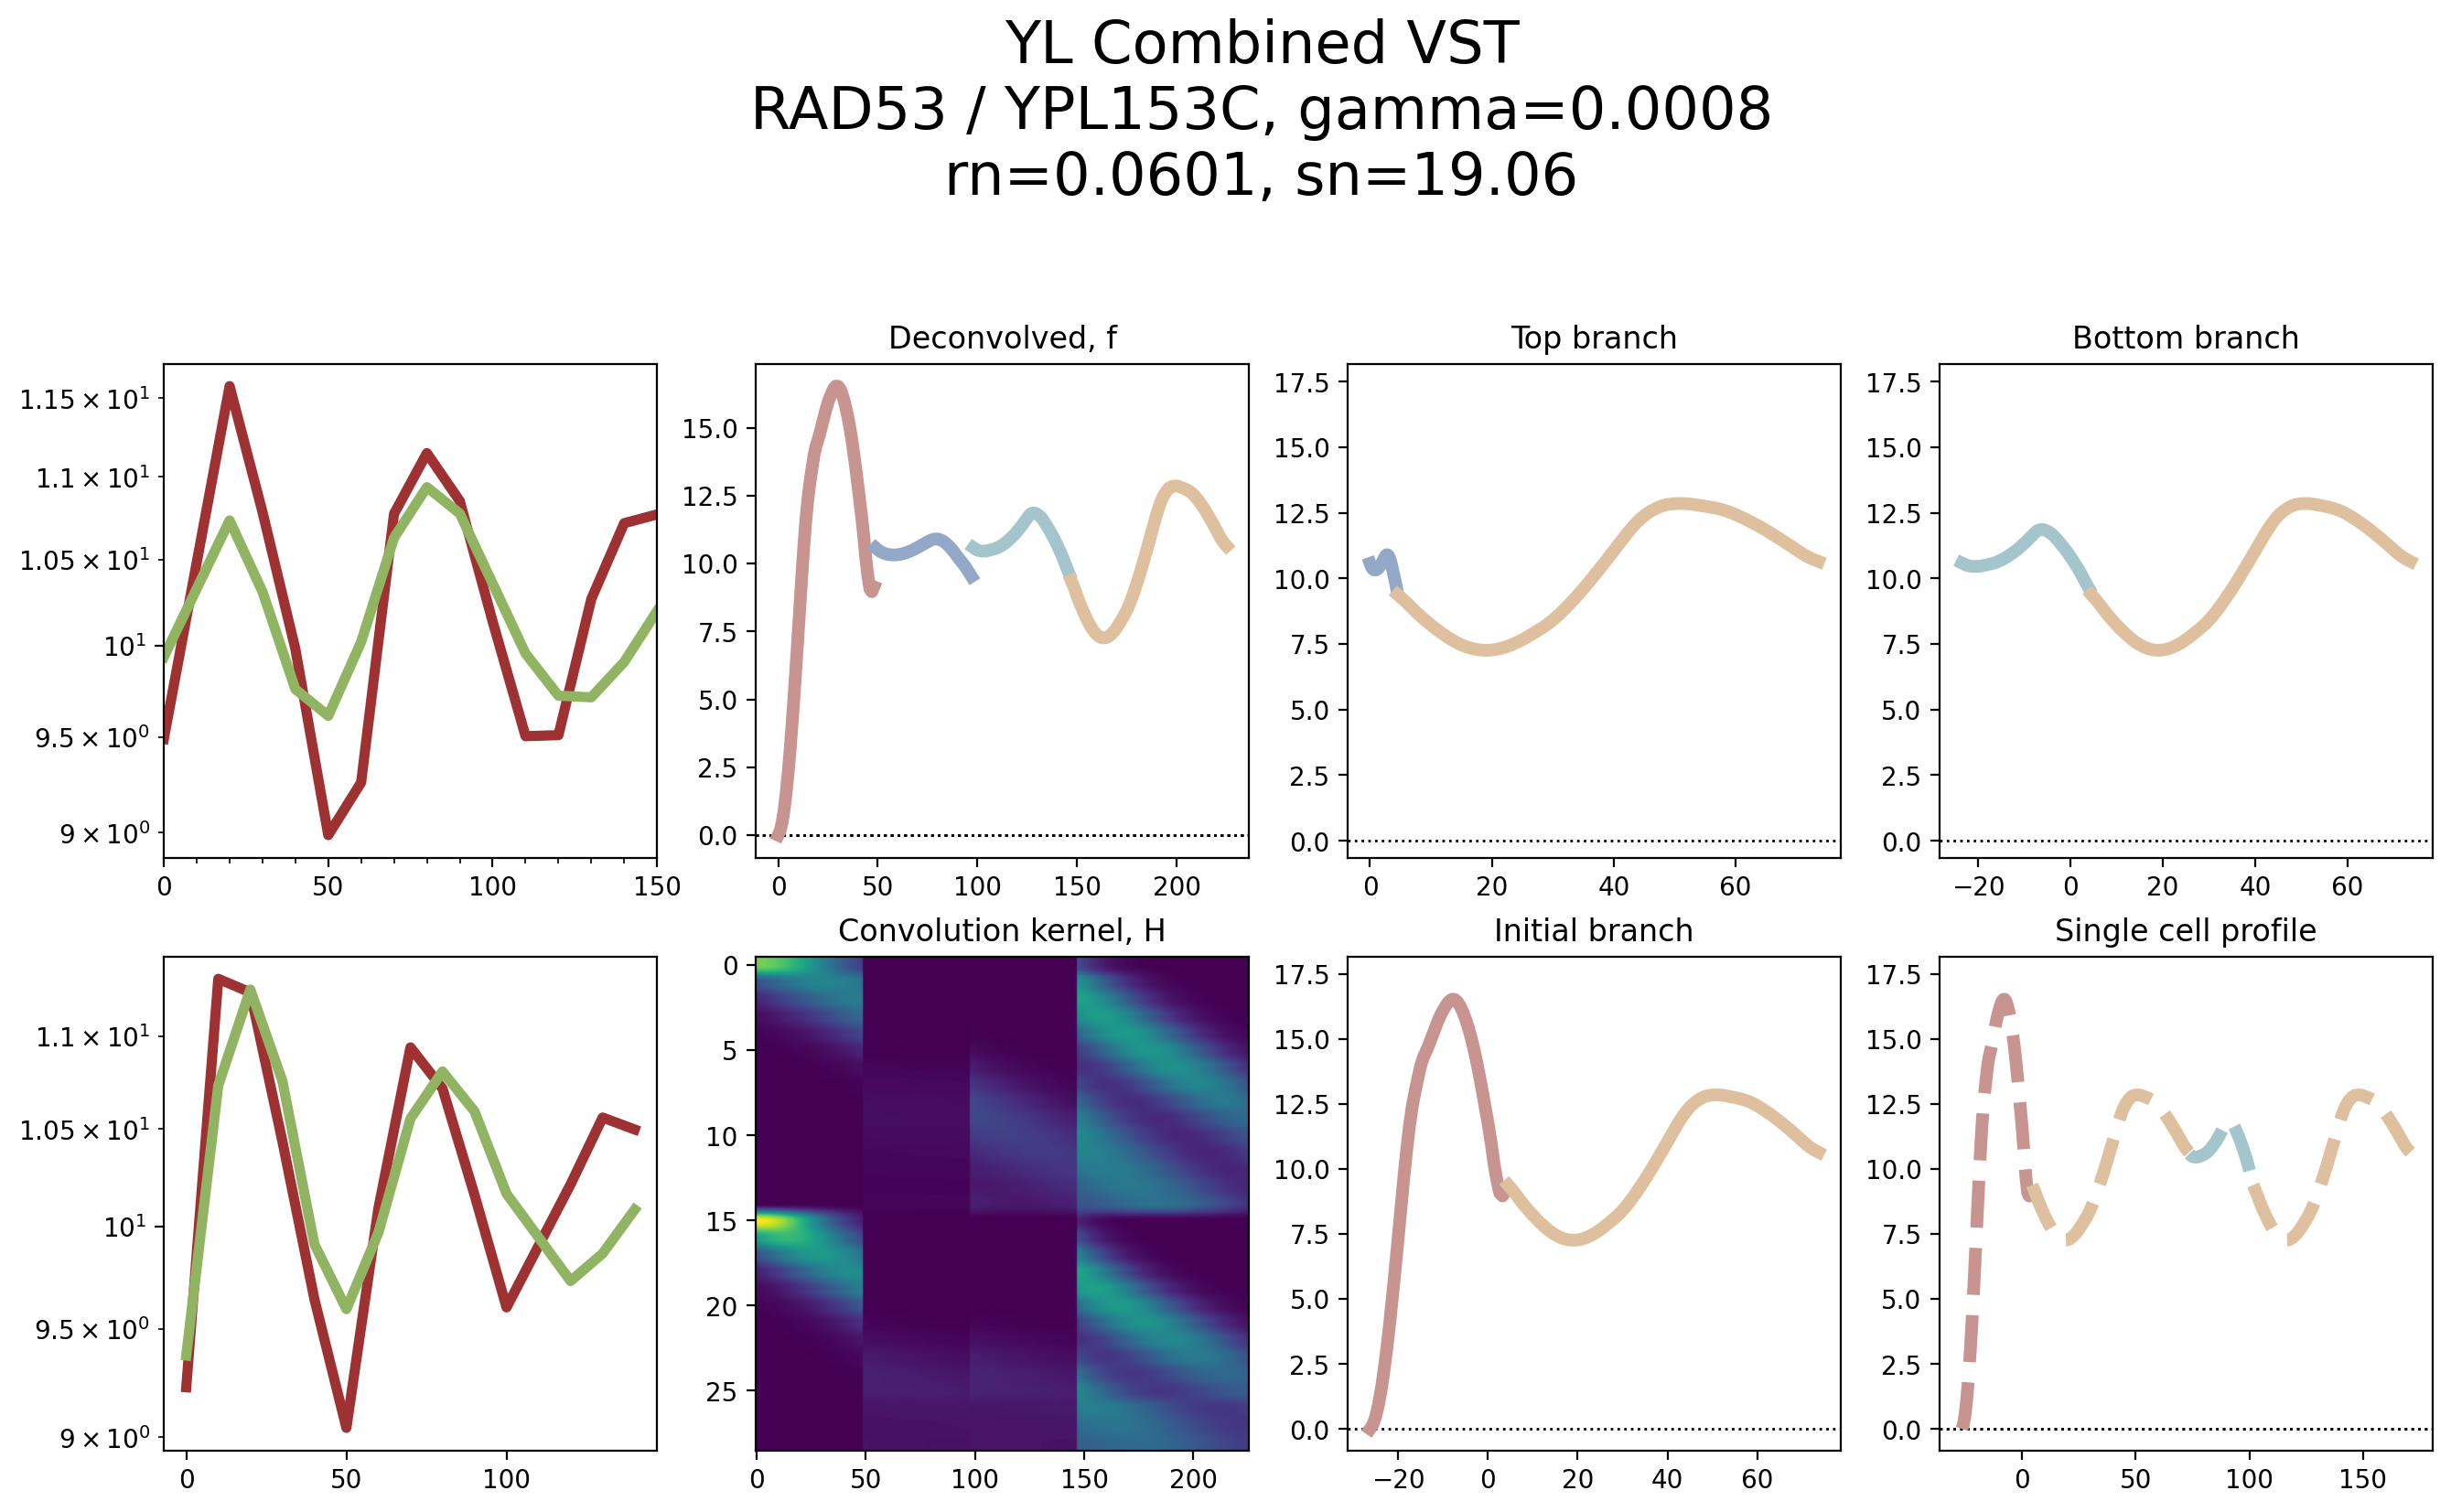

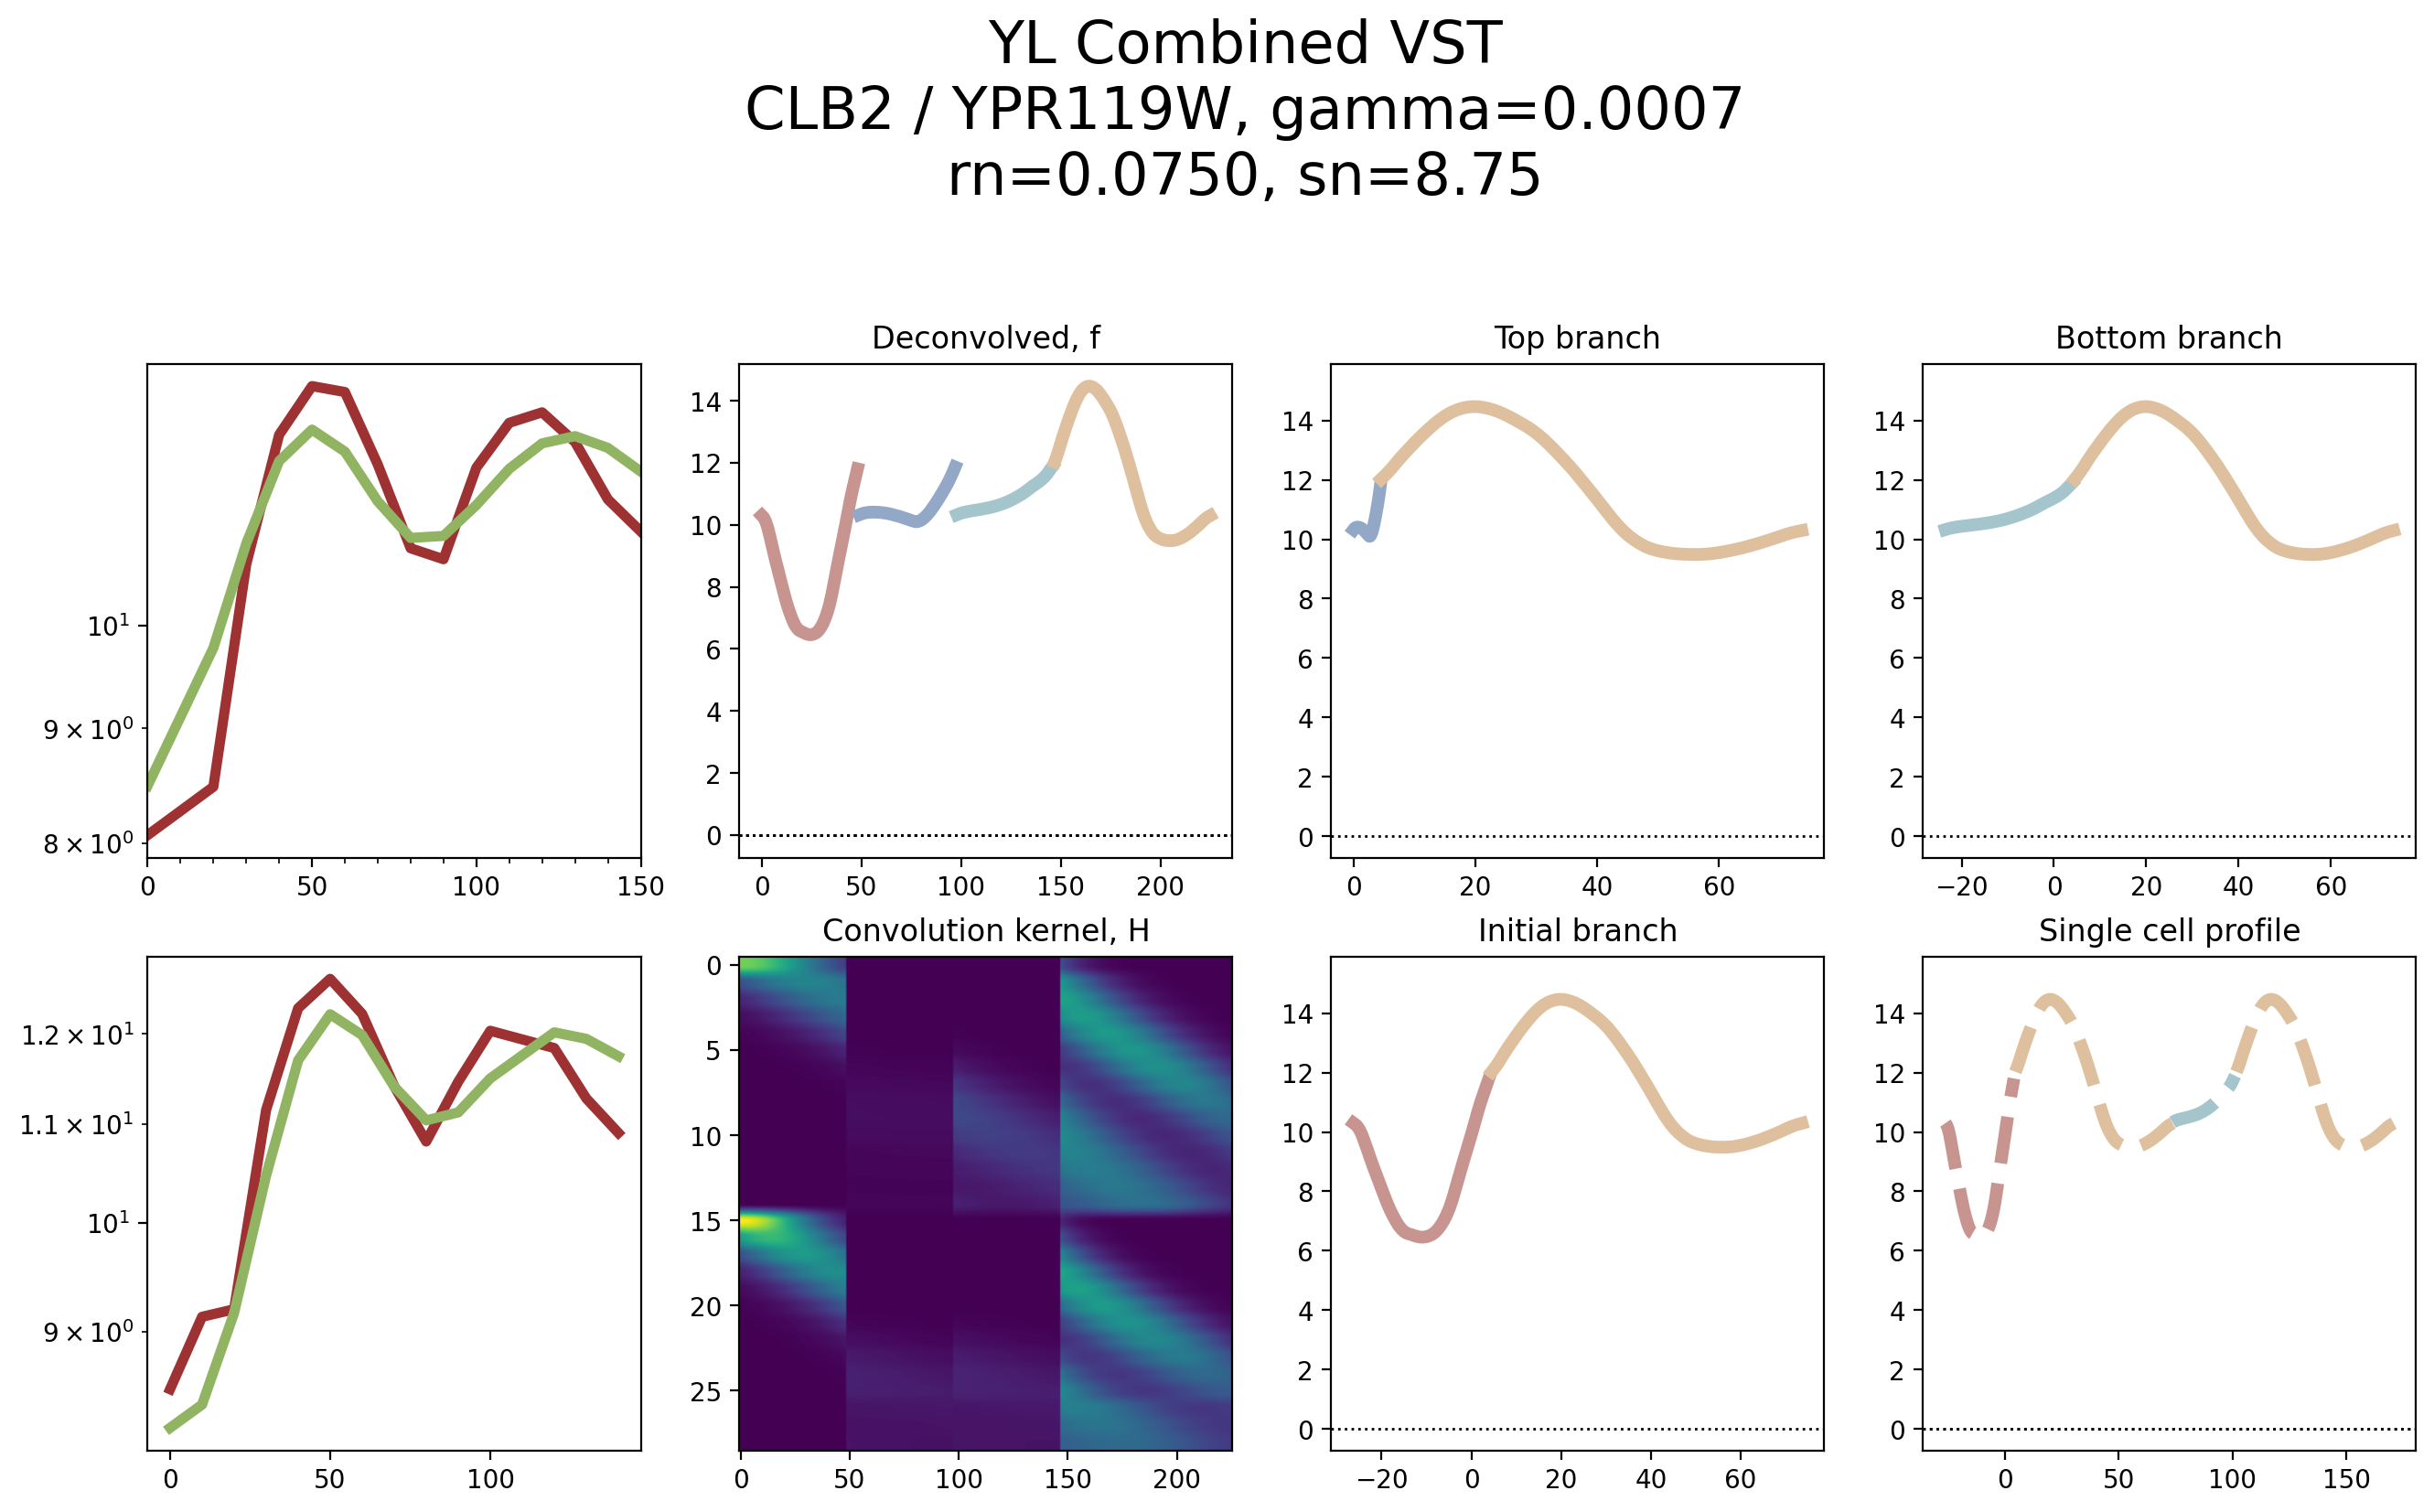

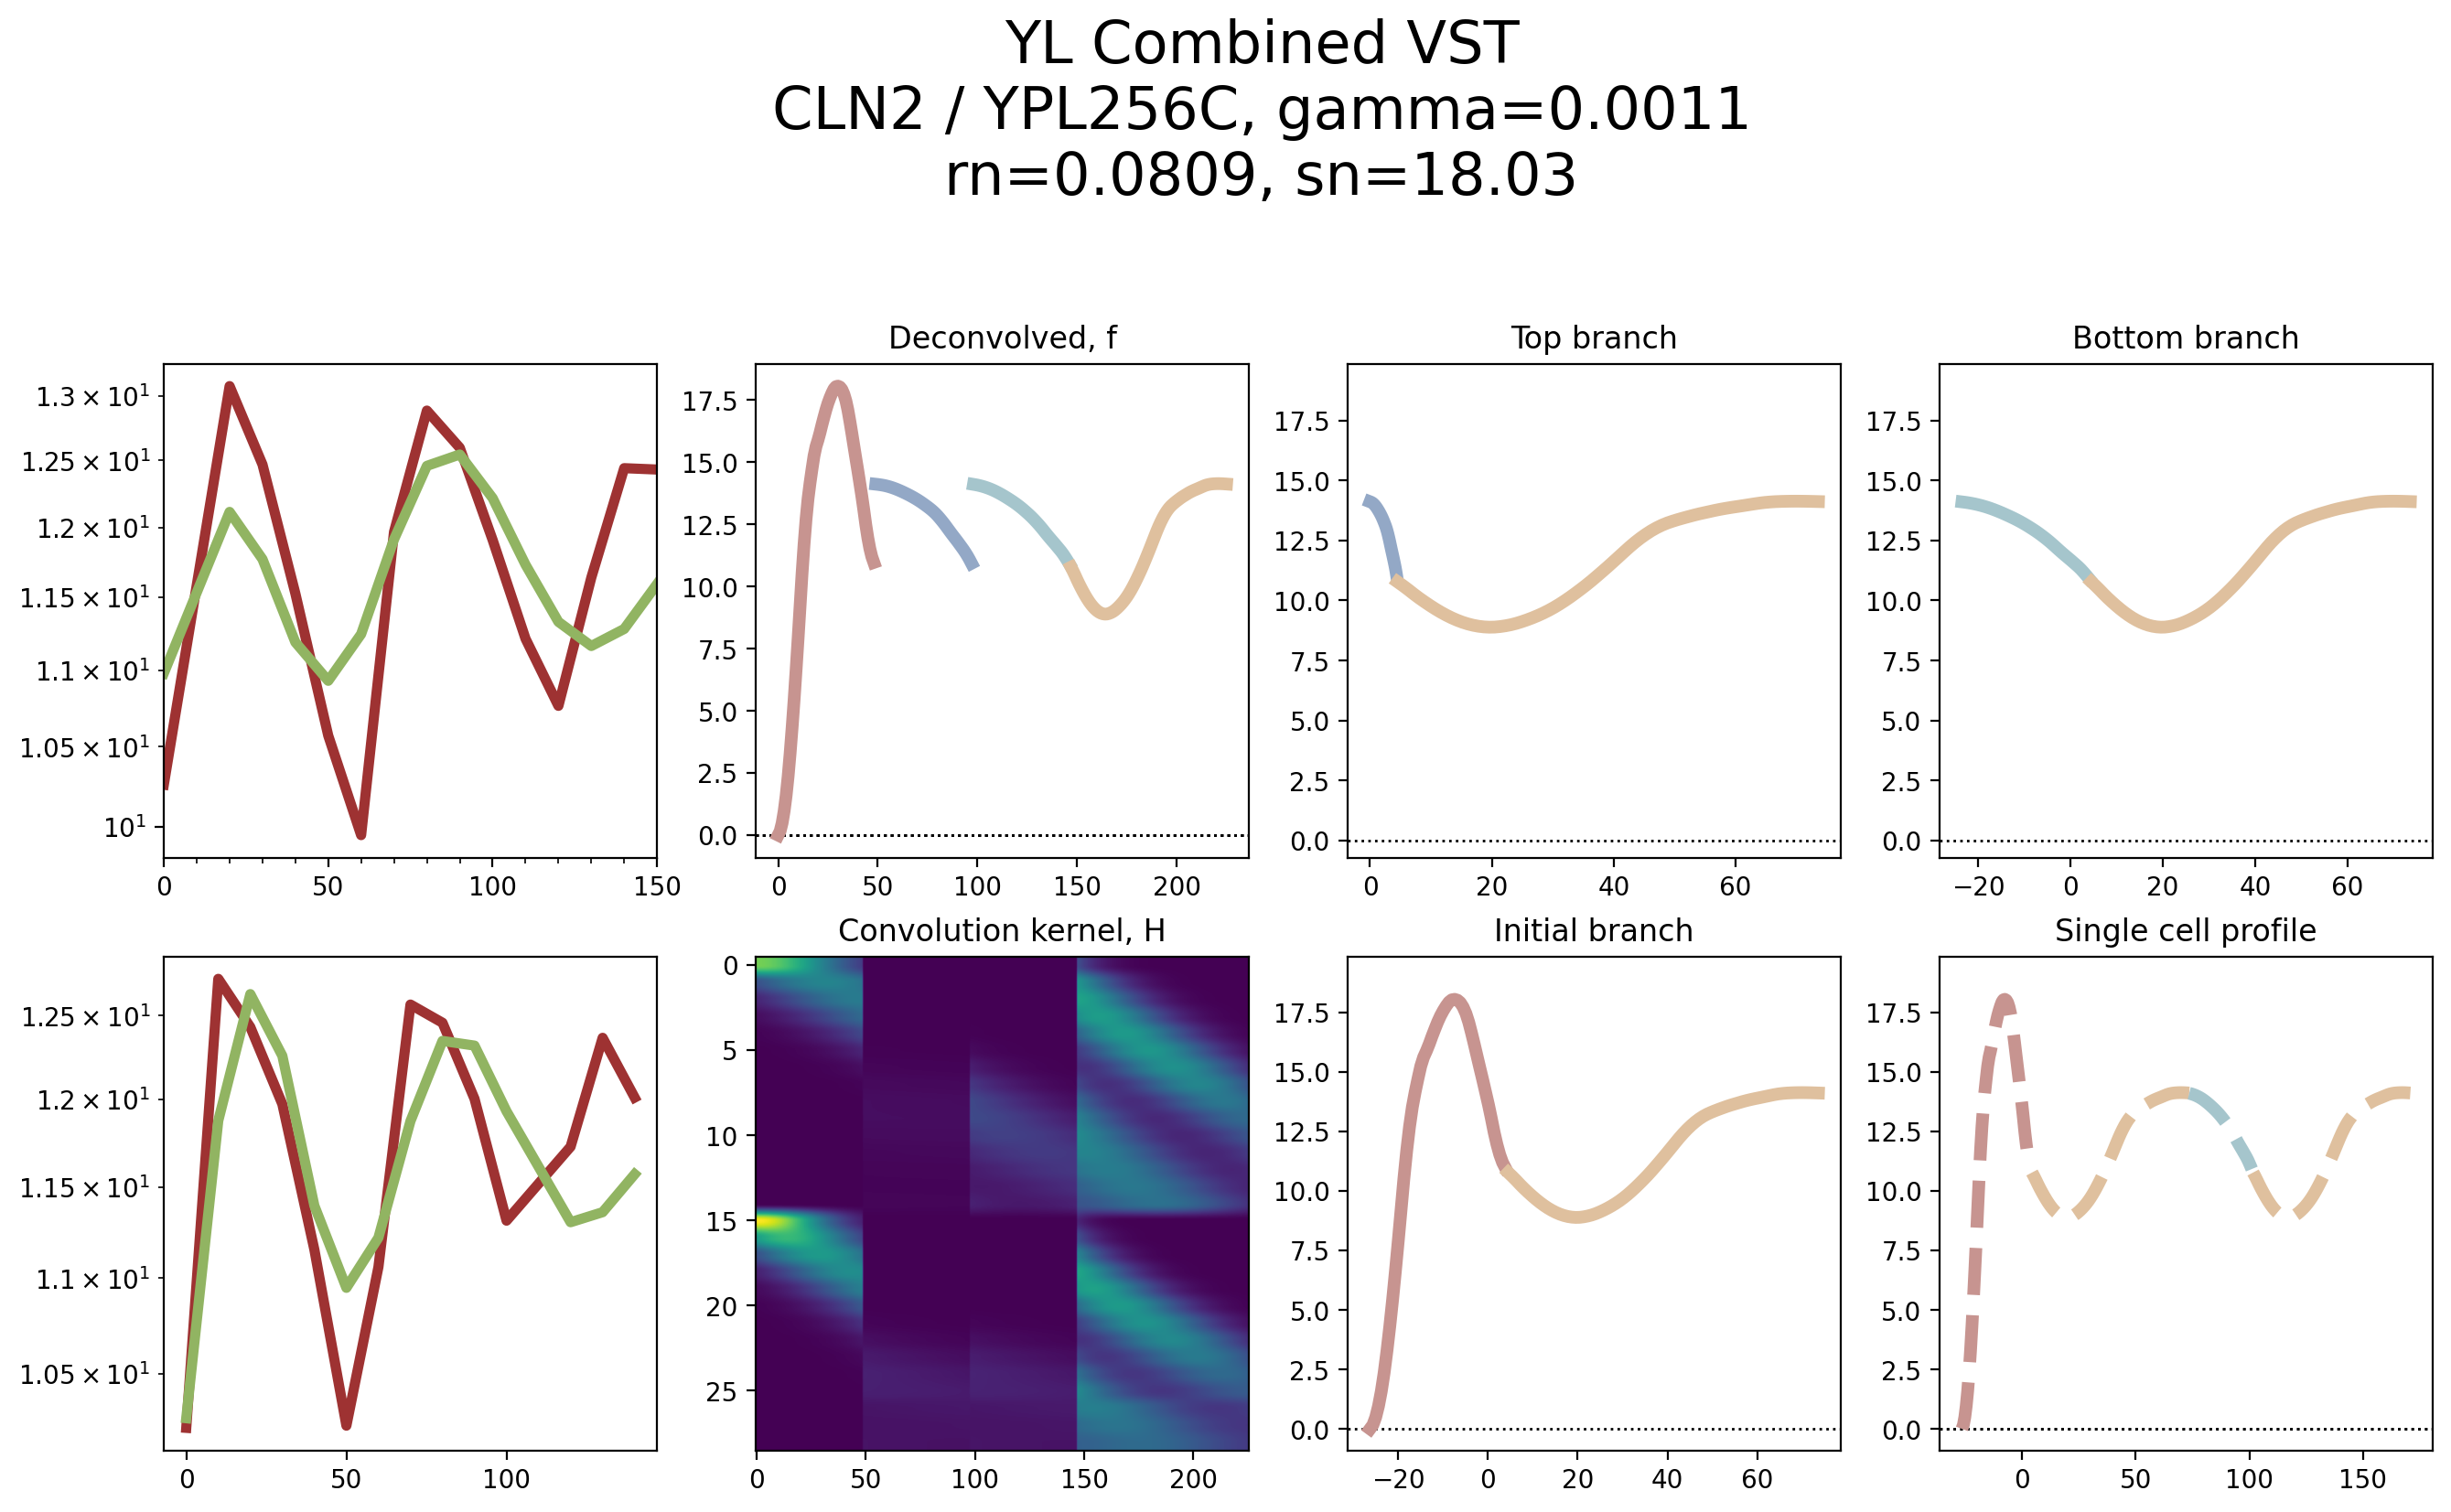

In [26]:
from cc_src.geneset import positive_control_genes
from src.find_gamma import FindOptimalGamma
    
outdir = 'output/positive_controls/'
default_gamma = 0.001

for gene in positive_control_genes():
    
    print(f"Deconvolving {gene}")
    try:
        vst_model = Model(rep1_vst_config, gene, default_gamma)
        find_gamma = FindOptimalGamma(vst_model)
        find_gamma.find_optimal()
    except ValueError:
        print("    Skipping.")
        continue

    vst_model.plot_deconvolved_gene(abbreviated=False)    
    savepath = f"{outdir}/{gene}.png"
    plt.savefig(savepath, dpi=150)
    print(f"Wrote to {savepath}")
